# Sprint 1c — Clustering de Regimes Operacionais (v3)

**Objetivo:** Identificar regimes operacionais do moinho de bolas a partir dos dados de processo,
utilizando técnicas de clustering (KMeans, GMM, DBSCAN) com pré-processamento avançado.

## Melhorias v3 em relação à v2
| # | Melhoria | Justificativa |
|---|----------|---------------|
| 1 | **Filtro de operação estável** | Remove paradas, partidas e transientes — clustering apenas com dados de operação real |
| 2 | **Feature engineering** | Energia específica (kWh/t), razão potência/alimentação, médias móveis 5min |
| 3 | **Persistência dual (disco + banco)** | Rastreabilidade completa — dashboard + reprodutibilidade local |
| 4 | **Comparação v1 vs v2 vs v3** | Evolução completa do pipeline de clustering |

## Pipeline
1. Carregar dados limpos (banco ou disco via `DATA_SOURCE`)
2. Filtrar operação estável (TPH > limiar, potência > limiar)
3. Seleção de features (conhecimento de domínio)
4. Feature engineering (variáveis derivadas)
5. Capping de limites operacionais
6. Hampel filter (de-spiking)
7. Remoção de quasi-constantes
8. Remoção de colinearidade (Pearson > 0.95)
9. Normalização com RobustScaler
10. Clustering: KMeans (GPU), GMM, DBSCAN
11. Seleção do melhor modelo
12. Caracterização dos regimes
13. Visualizações
14. Comparação v1 vs v2 vs v3
15. Salvar saídas (disco + banco)

**Entrada:** `data/processed/dataset_limpo.parquet` ou tabela `s1a_dados_limpos` (PostgreSQL)
**Saída:** `data/processed/dados_com_clusters_v3.parquet`, figuras em `figures/s1c_v3/`, tabelas PostgreSQL (`s1c_dados_com_clusters`, `s1c_metricas_clustering`, `s1c_regimes`, `s1c_regime_centroides`, `stage_images`)


## 1. Setup: Caminhos e Imports

**Objetivo:** Configurar os caminhos do projeto, importar as bibliotecas necessárias (NumPy, Pandas, Scikit-learn, PyTorch, Matplotlib, Seaborn), estabelecer conexão com o banco de dados PostgreSQL e criar as tabelas de saída de forma idempotente.

**Justificativa:** A centralização da configuração no início do notebook garante reprodutibilidade e facilita a manutenção. A criação idempotente das tabelas (`IF NOT EXISTS`) permite re-executar o notebook sem efeitos colaterais no schema do banco.


In [3]:
import sys, os, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW    = PROJECT_ROOT / "data" / "raw"
DATA_PROC   = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures" / "01_sprint1" / "clustering_v3"

# Garantir diretórios
for d in [DATA_PROC, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import torch
    TORCH_AVAILABLE = True
    if not hasattr(torch, "linalg"):
        raise ImportError(f"PyTorch {torch.__version__} não tem torch.linalg (requer >=1.9)")
except ImportError as e:
    raise ImportError(
        f"PyTorch é requisito obrigatório para este notebook (KMeans GPU + PCA GPU). "
        f"Instale com: pip install torch. Erro: {e}"
    )

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Visualização
sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.max_open_warning"] = 50

# Acesso ao banco de dados
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from db_utils import salvar_dataframe, salvar_imagem, criar_tabelas

# Criar schema e tabelas (idempotente)
criar_tabelas()

STAGE   = "s1c"
VERSAO  = "v3"
K_RANGE = range(2, 9)
N_CPU   = -1  # sklearn/joblib: -1 = usar todos os cores (evita bug loky no Windows)
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("GPU não disponível — usando CPU (execução mais lenta)")

print(f"PyTorch: {torch.__version__}")
print(f"CPU cores: {os.cpu_count()}")
print(f"Device: {DEVICE}")
t0 = time.time()

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
GPU: NVIDIA GeForce RTX 5070 Laptop GPU (8.5 GB)
PyTorch: 2.10.0+cu128
CPU cores: 24
Device: cuda


## 2. Carregar Dados Limpos

**Objetivo:** Carregar o dataset limpo produzido na Sprint 1a, contendo aproximadamente 632 mil registros e 26 variáveis de processo do moinho de bolas.

**Parâmetros:** A função `carregar_dados()` utiliza a configuração `DATA_SOURCE` para decidir a origem dos dados — leitura direta do PostgreSQL (tabela `s1a_dados_limpos`) ou do arquivo parquet local (`data/processed/dataset_limpo.parquet`).

**Justificativa:** A abstração da fonte de dados permite flexibilidade entre ambientes de desenvolvimento (disco local) e produção (banco de dados), sem alteração no código de análise.


In [4]:
import re
from db_utils import carregar_dados

# Carregar dados limpos do PostgreSQL (saída do S1a)
try:
    df = carregar_dados("dados_limpos")
except Exception as e:
    raise RuntimeError(
        f"Falha ao carregar 'dados_limpos' do banco. "
        f"Execute o notebook a_preparacao_dados.ipynb primeiro. Erro: {e}"
    )

df = df.drop(columns=["id"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# Colunas de processo
COLS_TODAS = list(df.columns)

# Função auxiliar para nomes curtos nas visualizações
def nome_curto(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

NOMES_CURTOS = {c: nome_curto(c) for c in COLS_TODAS}

# Identificar colunas-chave (com validação)
def _find_col(cols, keyword, label):
    matches = [c for c in cols if keyword in c.upper()]
    if not matches:
        raise ValueError(f"Nenhuma coluna com '{keyword}' encontrada para {label}. Colunas: {cols[:5]}...")
    return matches[0]

col_tph     = _find_col(COLS_TODAS, "BALANÇA", "TPH")
col_pot     = _find_col(COLS_TODAS, "POTÊNCIA", "Potência")
col_rot     = _find_col(COLS_TODAS, "ROTAÇÃO", "Rotação")
col_torque  = _find_col(COLS_TODAS, "TORQUE", "Torque")
col_corr_mo = _find_col(COLS_TODAS, "MO01 _ CORRENTE", "Corrente MO01")

print(f"Dataset: {df.shape[0]:,} registros x {df.shape[1]} variáveis")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"\nColunas-chave:")
print(f"  TPH:      {col_tph}")
print(f"  Potência: {col_pot}")
print(f"  Rotação:  {col_rot}")
print(f"  Torque:   {col_torque}")
print(f"  Corrente: {col_corr_mo}")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_limpos
Dataset: 632,985 registros x 27 variáveis
Período: 2024-08-01 00:00:00 a 2026-03-01 00:00:00

Colunas-chave:
  TPH:      1025_RETOMADA _ TR02 _ BALANÇA_pipoint
  Potência: 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint
  Rotação:  1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint
  Torque:   1030_MOAGEM _ MO01 _ TORQUE_pipoint
  Corrente: 1030_MOAGEM _ MO01 _ CORRENTE_pipoint


## 3. Filtro de Operação Estável

Remove registros de **paradas** (moinho desligado) e **transientes** (partidas/paradas),
mantendo apenas dados de operação estável para o clustering.

Critérios:
- TPH (alimentação) > limiar mínimo → moinho em produção
- Potência > limiar mínimo → moinho ligado e carregado
- Remoção de transientes: janela de 15 min após retomada de operação


Registros originais:     632,985
Moinho operando:         632,985 (100.0%)
Removidos (parada/idle): 0 (0.0%)
Transientes removidos:   15 (janela 15min após retomada)

Operação estável final:  632,970 (100.0%)
Período: 2024-08-01 00:15:00 a 2026-03-01 00:00:00
[db_utils] Imagem 'filtro_operacao_estavel' salva para etapa s1c


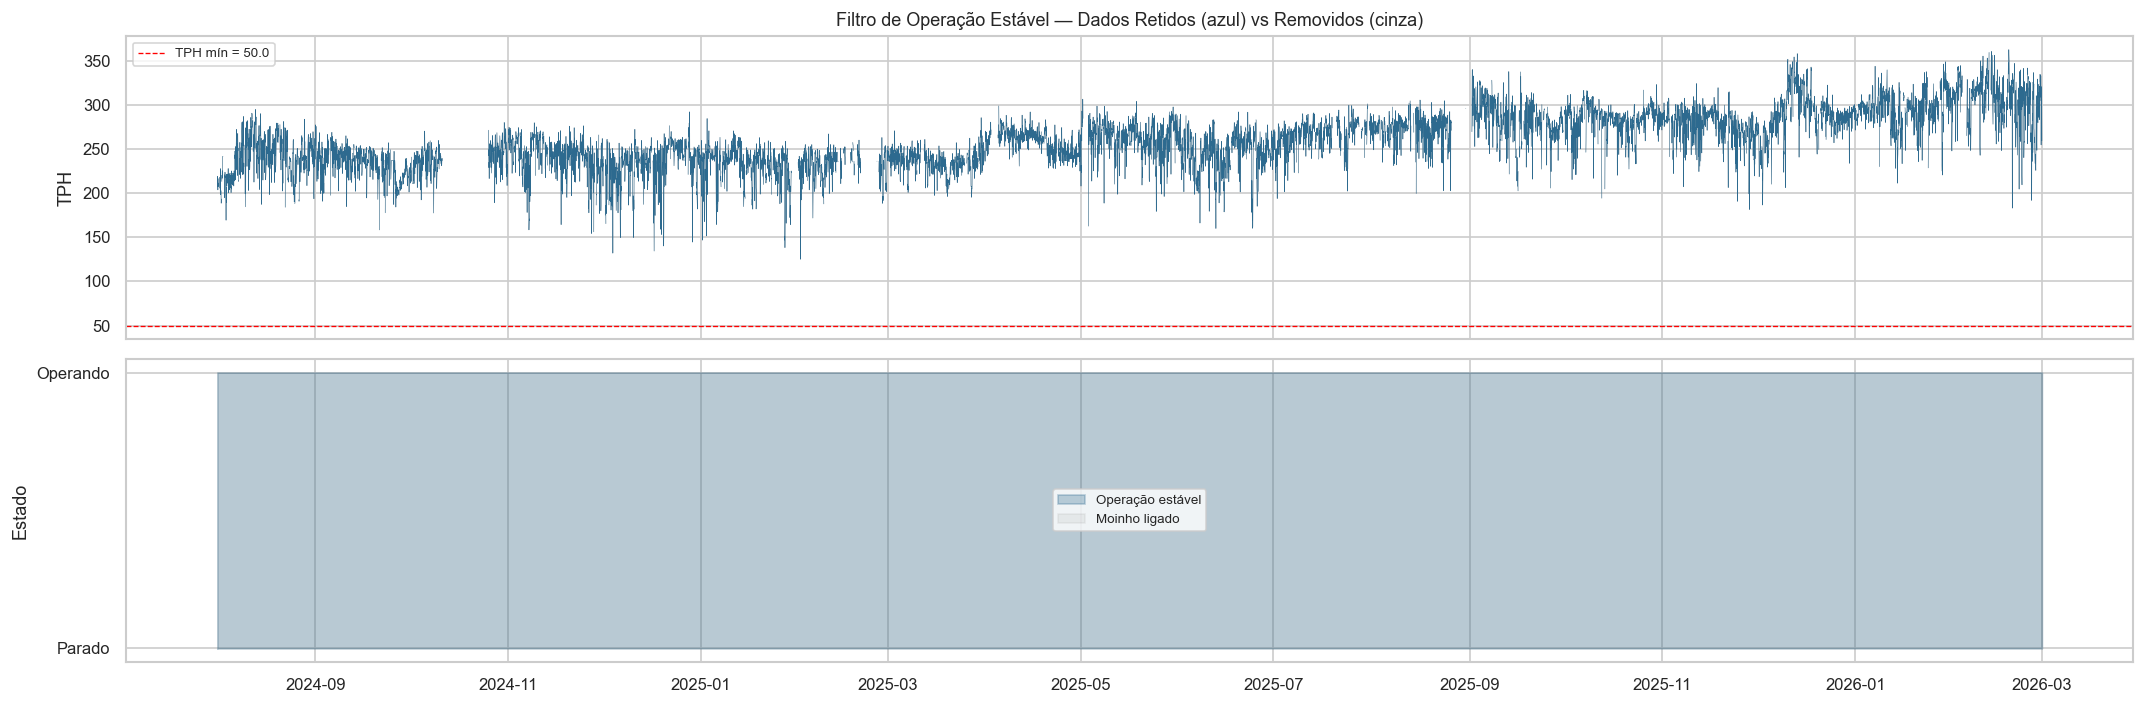

In [5]:
# ── Limiares de operação estável ──
# Baseados no conhecimento de domínio da planta
TPH_MIN  = 50.0    # t/h mínimo para considerar operação ativa
POT_MIN  = 500.0   # kW mínimo para considerar moinho ligado

n_total = len(df)

# Filtrar registros com moinho em operação
mask_operando = (df[col_tph] > TPH_MIN) & (df[col_pot] > POT_MIN)
print(f"Registros originais:     {n_total:,}")
print(f"Moinho operando:         {mask_operando.sum():,} ({100*mask_operando.sum()/n_total:.1f}%)")
print(f"Removidos (parada/idle): {(~mask_operando).sum():,} ({100*(~mask_operando).sum()/n_total:.1f}%)")

# ── Remoção de transientes ──
# Identificar retomadas: sequência False→True em mask_operando
# Remover 15 minutos após cada retomada (partida/aquecimento)
TRANSIENTE_MIN = 15  # minutos

mask_inicio = mask_operando & (~mask_operando.shift(1, fill_value=False))
idx_inicios = df.index[mask_inicio]

mask_transiente = pd.Series(False, index=df.index)
for t_inicio in idx_inicios:
    t_fim = t_inicio + pd.Timedelta(minutes=TRANSIENTE_MIN)
    mask_transiente |= (df.index >= t_inicio) & (df.index < t_fim)

n_transientes = (mask_operando & mask_transiente).sum()
print(f"Transientes removidos:   {n_transientes:,} (janela {TRANSIENTE_MIN}min após retomada)")

# Filtro final: operando E não transiente
mask_estavel = mask_operando & ~mask_transiente
df_estavel = df[mask_estavel].copy()

print(f"\nOperação estável final:  {len(df_estavel):,} ({100*len(df_estavel)/n_total:.1f}%)")
print(f"Período: {df_estavel.index.min()} a {df_estavel.index.max()}")

# Visualizar distribuição de operação
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

# TPH ao longo do tempo (amostra horária)
tph_h = df[col_tph].resample("1h").mean()
axes[0].plot(tph_h.index, tph_h.values, linewidth=0.3, color="gray", alpha=0.5)
tph_est = df_estavel[col_tph].resample("1h").mean()
axes[0].plot(tph_est.index, tph_est.values, linewidth=0.3, color="#2d6a8f")
axes[0].axhline(TPH_MIN, color="red", linestyle="--", linewidth=0.8, label=f"TPH mín = {TPH_MIN}")
axes[0].set_ylabel("TPH")
axes[0].set_title("Filtro de Operação Estável — Dados Retidos (azul) vs Removidos (cinza)")
axes[0].legend(fontsize=8)

# Máscara binária
axes[1].fill_between(df.index, mask_estavel.astype(int), alpha=0.3, color="#2d6a8f", label="Operação estável")
axes[1].fill_between(df.index, mask_operando.astype(int), alpha=0.1, color="gray", label="Moinho ligado")
axes[1].set_ylabel("Estado")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Parado", "Operando"])
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_01_filtro_operacao_estavel.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "filtro_operacao_estavel", fig, "S1c_01_filtro_operacao_estavel.png")
plt.show()


## 4. Seleção de Features (Conhecimento de Domínio)

Remove variáveis que não contribuem para a identificação de regimes operacionais:
- Área upstream (britagem)
- Setpoints fixos
- Sensores com falha ou >50% NaN
- Variáveis de sistemas auxiliares com pouca relação com o regime do moinho


In [6]:
# Padrões de variáveis a descartar
DESCARTAR_PATTERNS = [
    "BRITAGEM",                     # Área upstream
    "RETOMADA_SL01",                # >50% NaN
    "AL01 _ SETPOINT",              # Setpoints fixos
    "AL02 _ SETPOINT",
    "AL03 _ SETPOINT",
    "HCALIMENTAÇÃO _ VAZÃO",        # Falha sensor
    "HCALIMENTAÇÃO _ DENSIDADE",    # Não discriminante
    "MO01ÁGUADESCARGAMOINHO",       # Erros instrumento
    "MO01_VAZAO",                   # Erros instrumento
    "MO01MANCALENTRADA",            # Redundante com mancal saída
    "TR01 _ TRANSMISSORDEPESO",     # Variabilidade + gaps
]

COLS_EXPERT = []
descartadas = []
for col in COLS_TODAS:
    if any(pat.upper() in col.upper() for pat in DESCARTAR_PATTERNS):
        descartadas.append(col)
    else:
        COLS_EXPERT.append(col)

print(f"Variáveis originais:     {len(COLS_TODAS)}")
print(f"Variáveis selecionadas:  {len(COLS_EXPERT)}")
print(f"Descartadas ({len(descartadas)}):")
for c in descartadas:
    print(f"  - {c}")
print(f"\nVariáveis mantidas ({len(COLS_EXPERT)}):")
for c in COLS_EXPERT:
    print(f"  + {c}")


Variáveis originais:     27
Variáveis selecionadas:  16
Descartadas (11):
  - 1010_BRITAGEM _ SL01 _ NÍVEL_pipoint
  - 1025_RETOMADA_SL01_NIVEL_pipoint
  - 1025_RETOMADA _ AL01 _ SETPOINT_pipoint
  - 1025_RETOMADA _ AL02 _ SETPOINT_pipoint
  - 1025_RETOMADA _ AL03 _ SETPOINT_pipoint
  - 1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint
  - 1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint
  - 1030_MOAGEM _ MO01MANCALENTRADA _ PRESSÃO_pipoint
  - 1030_MOAGEM _ MO01ÁGUADESCARGAMOINHO _ VAZÃO_pipoint
  - 1030_MOAGEM _ MO01_VAZAO_pipoint
  - 1030_MOAGEM _ TR01 _ TRANSMISSORDEPESO_pipoint

Variáveis mantidas (16):
  + 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
  + 1025_RETOMADA _ TR02 _ CORRENTE_pipoint
  + 1030_MOAGEM _ CX01 _ NÍVEL_pipoint
  + 1030_MOAGEM _ HC _ PRESSÃO_pipoint
  + 1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint
  + 1030_MOAGEM _ MO01 _ CORRENTE_pipoint
  + 1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint
  + 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint
  + 1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint

## 5. Feature Engineering

Cria variáveis derivadas com significado operacional:

| Variável | Fórmula | Significado |
|----------|---------|-------------|
| **Energia Específica** | Potência / TPH | kWh/t — eficiência energética da moagem |
| **Razão Torque/Potência** | Torque / Potência | Condição de carga do moinho |
| **Média Móvel TPH (5min)** | rolling(5).mean() | Suaviza oscilações de curto prazo |
| **Desvio Móvel TPH (5min)** | rolling(5).std() | Captura instabilidade na alimentação |
| **Média Móvel Potência (5min)** | rolling(5).mean() | Tendência de consumo energético |


In [7]:
# ── Variáveis derivadas ──
# Energia específica: kWh por tonelada processada
df_estavel["FEAT_energia_especifica"] = (
    df_estavel[col_pot] / df_estavel[col_tph].replace(0, np.nan)
)

# Razão torque/potência: indicador de condição de carga
df_estavel["FEAT_razao_torque_potencia"] = (
    df_estavel[col_torque] / df_estavel[col_pot].replace(0, np.nan)
)

# Médias móveis (5 min) — suavizam oscilações de curto prazo
df_estavel["FEAT_tph_mm5"] = df_estavel[col_tph].rolling(5, min_periods=1).mean()
df_estavel["FEAT_tph_std5"] = df_estavel[col_tph].rolling(5, min_periods=1).std().fillna(0)
df_estavel["FEAT_pot_mm5"] = df_estavel[col_pot].rolling(5, min_periods=1).mean()

# Listar features derivadas
COLS_FEAT = [c for c in df_estavel.columns if c.startswith("FEAT_")]
print(f"Features derivadas criadas: {len(COLS_FEAT)}")
for c in COLS_FEAT:
    vals = df_estavel[c].dropna()
    print(f"  {c}: mean={vals.mean():.2f}, std={vals.std():.2f}, "
          f"min={vals.min():.2f}, max={vals.max():.2f}")

# Atualizar lista de colunas para clustering
COLS_CLUSTER_RAW = COLS_EXPERT + COLS_FEAT
print(f"\nTotal variáveis para clustering (antes do preprocessing): {len(COLS_CLUSTER_RAW)}")


Features derivadas criadas: 5
  FEAT_energia_especifica: mean=9.74, std=2.35, min=3.37, max=44.73
  FEAT_razao_torque_potencia: mean=0.28, std=0.06, min=0.11, max=0.48
  FEAT_tph_mm5: mean=260.42, std=34.76, min=75.97, max=412.99
  FEAT_tph_std5: mean=17.54, std=17.78, min=0.00, max=183.95
  FEAT_pot_mm5: mean=2468.12, std=331.71, min=1355.14, max=3209.63

Total variáveis para clustering (antes do preprocessing): 21


## 6. Pipeline de Preprocessing

Sequência:
1. Capping de limites operacionais (sensores de nível ≤ 100%)
2. Hampel filter (de-spiking, janela=15, k=3.0)
3. Remoção de quasi-constantes (freq > 98% ou std < 1e-8)
4. Remoção de colinearidade (Pearson > 0.95)
5. Normalização com RobustScaler (mediana/IQR)


In [8]:
# ── 6.1 Capping de limites operacionais ──
LIMITE_NIVEL = 100.0
cols_nivel = [c for c in COLS_CLUSTER_RAW if "NÍVEL" in c.upper() or "NIVEL" in c.upper()]
total_capped = 0

for col in cols_nivel:
    mask = df_estavel[col] > LIMITE_NIVEL
    n_capped = mask.sum()
    if n_capped > 0:
        df_estavel.loc[:, col] = df_estavel[col].clip(upper=LIMITE_NIVEL)
        total_capped += n_capped
        print(f"  Capped {col}: {n_capped:,} valores")

print(f"Total valores capped: {total_capped:,}")


  Capped 1030_MOAGEM _ CX01 _ NÍVEL_pipoint: 6,351 valores
  Capped 2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint: 7,057 valores
Total valores capped: 13,408


In [9]:
# ── 6.2 Hampel Filter (de-spiking vetorizado) ──
HAMPEL_JANELA = 15
HAMPEL_K      = 3.0
HAMPEL_SCALE  = 1.4826  # Fator MAD → σ

total_spikes = 0
t_hampel = time.time()

for col in COLS_CLUSTER_RAW:
    median_vals = df_estavel[col].rolling(window=HAMPEL_JANELA, center=True).median()
    mad_vals = (df_estavel[col] - median_vals).abs().rolling(window=HAMPEL_JANELA, center=True).median()
    threshold = HAMPEL_K * HAMPEL_SCALE * mad_vals
    mask_spike = (df_estavel[col] - median_vals).abs() > threshold
    n_spikes = mask_spike.sum()
    if n_spikes > 0:
        df_estavel.loc[mask_spike, col] = median_vals.loc[mask_spike]
        total_spikes += n_spikes

n_cells = len(df_estavel) * len(COLS_CLUSTER_RAW)
print(f"Spikes removidos: {total_spikes:,} ({100*total_spikes/n_cells:.2f}%)")
print(f"Tempo Hampel: {time.time() - t_hampel:.1f}s")


Spikes removidos: 794,819 (5.98%)
Tempo Hampel: 10.0s


In [10]:
# ── 6.3 Remoção de quasi-constantes ──
LIMIAR_FREQ = 0.98
LIMIAR_STD  = 1e-8

cols_quase_const = []
for col in COLS_CLUSTER_RAW:
    vc = df_estavel[col].dropna().value_counts(normalize=True)
    mode_freq = vc.iloc[0] if len(vc) > 0 else 0
    std_val = df_estavel[col].std()
    if mode_freq > LIMIAR_FREQ or std_val < LIMIAR_STD:
        cols_quase_const.append(col)

COLS_CLUSTER_RAW = [c for c in COLS_CLUSTER_RAW if c not in cols_quase_const]
print(f"Quasi-constantes removidas: {len(cols_quase_const)}")
for c in cols_quase_const:
    print(f"  - {c}")
print(f"Variáveis restantes: {len(COLS_CLUSTER_RAW)}")


Quasi-constantes removidas: 0
Variáveis restantes: 21


In [11]:
# ── 6.4 Remoção de colinearidade ──
LIMIAR_CORR = 0.95

corr_matrix = df_estavel[COLS_CLUSTER_RAW].corr(method="pearson").abs()
corr_vals = corr_matrix.values.copy()
np.fill_diagonal(corr_vals, 0)
corr_abs = pd.DataFrame(corr_vals, index=corr_matrix.index, columns=corr_matrix.columns)

# Variáveis originais (pipoint) têm prioridade sobre derivadas (FEAT_/MM_/STD_/LAG_/DIFF_)
def _is_derivada(col):
    """Retorna True se a coluna é uma feature derivada."""
    return any(col.startswith(p) for p in ("FEAT_", "MM_", "STD_", "LAG_", "DIFF_"))

cols_remove_corr = set()
for i in range(len(COLS_CLUSTER_RAW)):
    for j in range(i + 1, len(COLS_CLUSTER_RAW)):
        if corr_vals[i, j] >= LIMIAR_CORR:
            col_i, col_j = COLS_CLUSTER_RAW[i], COLS_CLUSTER_RAW[j]
            # Se uma é original e outra derivada, remover a derivada
            deriv_i = _is_derivada(col_i)
            deriv_j = _is_derivada(col_j)
            if deriv_i and not deriv_j:
                removed = col_i
            elif deriv_j and not deriv_i:
                removed = col_j
            else:
                # Ambas originais ou ambas derivadas: remover a de maior correlação média
                mean_corr_i = corr_abs[col_i].mean()
                mean_corr_j = corr_abs[col_j].mean()
                removed = col_j if mean_corr_j >= mean_corr_i else col_i
            cols_remove_corr.add(removed)
            print(f"  Par colinear: corr={corr_vals[i,j]:.3f}")
            print(f"    {col_i} ({'derivada' if deriv_i else 'original'}, mean_corr={corr_abs[col_i].mean():.3f})")
            print(f"    {col_j} ({'derivada' if deriv_j else 'original'}, mean_corr={corr_abs[col_j].mean():.3f})")
            print(f"    → Removida: {removed}")

COLS_CLUSTER = [c for c in COLS_CLUSTER_RAW if c not in cols_remove_corr]
print(f"\nColinearidade removida: {len(cols_remove_corr)} variáveis")
print(f"Variáveis finais para clustering: {len(COLS_CLUSTER)}")
for c in COLS_CLUSTER:
    print(f"  + {c}")

  Par colinear: corr=0.995
    1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint (original, mean_corr=0.292)
    FEAT_pot_mm5 (derivada, mean_corr=0.291)
    → Removida: FEAT_pot_mm5

Colinearidade removida: 1 variáveis
Variáveis finais para clustering: 20
  + 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
  + 1025_RETOMADA _ TR02 _ CORRENTE_pipoint
  + 1030_MOAGEM _ CX01 _ NÍVEL_pipoint
  + 1030_MOAGEM _ HC _ PRESSÃO_pipoint
  + 1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint
  + 1030_MOAGEM _ MO01 _ CORRENTE_pipoint
  + 1030_MOAGEM _ MO01 _ OUVIDOELETRÔNICO_pipoint
  + 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint
  + 1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint
  + 1030_MOAGEM _ MO01 _ TORQUE_pipoint
  + 1035_ESPESSAMENTO _ EP01ALIMENTAÇÃOCIL _ VAZÃO_pipoint
  + 1035_ESPESSAMENTO _ EP01 _ PH_pipoint
  + 1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint
  + 1065_DETOX _ CX01 _ NÍVEL_pipoint
  + 2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint
  + 2020_SISTEMADEÁGUA _ TQ02 _ NÍVEL_pipoint
  + FEAT_energia_especifica
  + FEAT_raz

In [12]:
# ── 6.5 Preparação final e normalização ──
# Verificar NaN
nan_pct = df_estavel[COLS_CLUSTER].isnull().mean()
cols_excluir_nan = nan_pct[nan_pct > 0.5].index.tolist()
if cols_excluir_nan:
    print(f"Colunas excluídas (>50% NaN): {cols_excluir_nan}")
    COLS_CLUSTER = [c for c in COLS_CLUSTER if c not in cols_excluir_nan]

# Remover linhas com NaN restantes
df_clean = df_estavel[COLS_CLUSTER].dropna()
print(f"Registros para clustering: {len(df_clean):,} ({100*len(df_clean)/len(df_estavel):.1f}%)")
print(f"Variáveis: {len(COLS_CLUSTER)}")

# Normalização com RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_clean)

# GPU tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)
print(f"Dados na GPU: {X_tensor.shape} ({X_tensor.element_size() * X_tensor.nelement() / 1e6:.0f} MB)")


Registros para clustering: 632,970 (100.0%)
Variáveis: 20
Dados na GPU: torch.Size([632970, 20]) (51 MB)


## 7. Implementações GPU

**Objetivo:** Implementar versões customizadas de KMeans e PCA utilizando PyTorch com aceleração por GPU (CUDA), visando desempenho adequado para o volume de dados (600 mil+ registros).

**Parâmetros:** O KMeans GPU utiliza inicialização k-means++ e múltiplos restarts (`n_init=10`) para robustez na convergência. O PCA GPU realiza decomposição SVD diretamente na memória da GPU.

**Justificativa:** As implementações do Scikit-learn são limitadas à CPU, tornando-se um gargalo computacional para datasets desta magnitude. A transferência das operações matriciais para a GPU reduz significativamente o tempo de execução, especialmente na etapa de avaliação com múltiplos valores de k e restarts.


In [13]:
def kmeans_gpu(X: torch.Tensor, k: int, max_iter: int = 300, n_init: int = 10, seed: int = 42):
    """KMeans na GPU via PyTorch."""
    n, d = X.shape
    best_labels = None
    best_inertia = float("inf")
    best_centers = None

    for init_i in range(n_init):
        rng = torch.Generator(device=X.device).manual_seed(seed + init_i)
        idx = torch.randperm(n, generator=rng, device=X.device)[:k]
        centers = X[idx].clone()

        for _ in range(max_iter):
            dists = torch.cdist(X, centers, p=2.0)
            labels = dists.argmin(dim=1)

            new_centers = torch.zeros_like(centers)
            for j in range(k):
                mask = labels == j
                if mask.any():
                    new_centers[j] = X[mask].mean(dim=0)
                else:
                    new_centers[j] = X[torch.randint(n, (1,), device=X.device)]

            shift = (new_centers - centers).norm()
            centers = new_centers
            if shift < 1e-6:
                break

        dists_final = torch.cdist(X, centers, p=2.0)
        inertia = (dists_final.min(dim=1).values ** 2).sum().item()

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.cpu().numpy()
            best_centers = centers.cpu().numpy()

    return best_labels, best_inertia, best_centers


def pca_gpu(X: torch.Tensor, n_components: int = 2):
    """PCA via SVD na GPU."""
    X_centered = X - X.mean(dim=0)
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)
    components = Vt[:n_components]
    X_proj = X_centered @ components.T
    var_total = (S ** 2).sum()
    var_explained = (S[:n_components] ** 2) / var_total
    return X_proj.cpu().numpy(), var_explained.cpu().numpy()


## 8. Avaliação de Algoritmos de Clustering

**Objetivo:** Avaliar sistematicamente três algoritmos de clustering — KMeans (GPU, k=2..8), GMM (CPU, k=2..8) e DBSCAN (CPU, eps automático via k-distance) — para identificar o método e número de clusters mais adequados aos dados de processo.

**Métricas de avaliação:**
- **Silhouette Score:** mede coesão intra-cluster e separação inter-cluster (quanto maior, melhor)
- **Davies-Bouldin Index:** razão entre dispersão intra-cluster e distância inter-cluster (quanto menor, melhor)
- **Calinski-Harabasz Index:** razão entre variância inter e intra-cluster (quanto maior, melhor)

**Justificativa:** A comparação entre algoritmos com pressupostos distintos (partição rígida no KMeans, modelos probabilísticos no GMM, densidade no DBSCAN) permite identificar qual abordagem melhor captura a estrutura dos regimes operacionais. Não se utiliza TimeSeriesSplit pois clustering é uma tarefa não supervisionada — a avaliação baseia-se exclusivamente em métricas internas de qualidade dos clusters.


In [14]:
# ── 8.1 KMeans (GPU) ──
print("--- Avaliando KMeans (GPU) ---")
resultados = []

for k in K_RANGE:
    t1 = time.time()
    labels, inertia, centers = kmeans_gpu(X_tensor, k)
    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "KMeans", "n_clusters": k,
        "silhouette": round(sil, 4), "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1), "inertia": round(inertia, 1),
        "bic": None, "selecionado": False, "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  ({dt:.1f}s)")


--- Avaliando KMeans (GPU) ---
  k=2: 2 clusters  Sil=0.1535  DB=2.2622  CH=105802  (25.3s)
  k=3: 3 clusters  Sil=0.1679  DB=1.8152  CH=118908  (25.1s)
  k=4: 4 clusters  Sil=0.1517  DB=1.7321  CH=108917  (22.1s)
  k=5: 5 clusters  Sil=0.1678  DB=1.6637  CH=102670  (22.4s)
  k=6: 6 clusters  Sil=0.1581  DB=1.6979  CH=94310  (22.5s)
  k=7: 7 clusters  Sil=0.1530  DB=1.7545  CH=86886  (21.5s)
  k=8: 8 clusters  Sil=0.1508  DB=1.8253  CH=79607  (20.2s)


In [15]:
# ── 8.2 GMM (CPU) ──
print("\n--- Avaliando GMM ---")

for k in K_RANGE:
    t1 = time.time()
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           n_init=3, max_iter=200, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=min(50000, len(X_scaled)),
                           random_state=42, n_jobs=N_CPU)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    dt = time.time() - t1

    resultados.append({
        "algoritmo": "GMM", "n_clusters": k,
        "silhouette": round(sil, 4), "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1), "inertia": None,
        "bic": round(bic, 1), "selecionado": False, "_labels": labels,
    })
    n_found = len(set(labels))
    print(f"  k={k}: {n_found} clusters  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.0f}  BIC={bic:.0f}  ({dt:.1f}s)")



--- Avaliando GMM ---
  k=2: 2 clusters  Sil=0.1152  DB=2.8040  CH=71491  BIC=13784599  (106.3s)
  k=3: 3 clusters  Sil=0.0895  DB=2.8632  CH=60936  BIC=11548222  (108.2s)
  k=4: 4 clusters  Sil=0.0912  DB=2.6195  CH=58277  BIC=10182111  (104.7s)
  k=5: 5 clusters  Sil=0.1080  DB=2.3087  CH=63626  BIC=9258120  (85.5s)
  k=6: 6 clusters  Sil=0.1018  DB=2.2247  CH=58685  BIC=8495197  (125.8s)
  k=7: 7 clusters  Sil=0.0961  DB=2.5356  CH=54184  BIC=8003878  (182.1s)
  k=8: 8 clusters  Sil=0.0906  DB=2.3732  CH=47407  BIC=7406536  (200.9s)


In [16]:
# ── 8.3 DBSCAN — sweep sistemático de eps × min_samples (dataset completo) ──
print("\n--- Avaliando DBSCAN (sweep sistemático, dataset completo) ---")

DBSCAN_MIN_SAMPLES_LIST = [6, 8, 10, 12]

# NearestNeighbors no dataset completo
nn = NearestNeighbors(n_neighbors=max(DBSCAN_MIN_SAMPLES_LIST), n_jobs=N_CPU)
nn.fit(X_scaled)
distances_all, _ = nn.kneighbors(X_scaled)

# Detecção de cotovelo via distância perpendicular máxima (método geométrico)
def knee_perpendicular(k_dists):
    """Encontra o ponto de cotovelo pela máxima distância perpendicular à reta endpoints."""
    y = np.sort(k_dists)
    n = len(y)
    x = np.arange(n)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / line_len
    points = np.column_stack([x, y])
    vecs = points - p1
    proj = np.dot(vecs, line_unit)[:, None] * line_unit
    perp = vecs - proj
    dists = np.linalg.norm(perp, axis=1)
    knee_idx = np.argmax(dists)
    return float(y[knee_idx])

# Estimar eps_centro usando min_samples mediano
k_ref = DBSCAN_MIN_SAMPLES_LIST[len(DBSCAN_MIN_SAMPLES_LIST) // 2]
k_dists_ref = distances_all[:, k_ref - 1]
eps_centro = knee_perpendicular(k_dists_ref)
print(f"  eps_centro (knee, k={k_ref}): {eps_centro:.4f}")

# Gerar faixa de eps: 50% a 100% do centro, em steps de 5%
eps_range = np.arange(0.50, 1.05, 0.05) * eps_centro
print(f"  eps_range: {eps_range.min():.4f} a {eps_range.max():.4f} ({len(eps_range)} valores)")
print(f"  min_samples: {DBSCAN_MIN_SAMPLES_LIST}")
print(f"  Dataset: {len(X_scaled):,} registros (100%)")

# Sweep: testar cada combinação
dbscan_results = []
for ms in DBSCAN_MIN_SAMPLES_LIST:
    for eps_val in eps_range:
        t1 = time.time()
        dbscan = DBSCAN(eps=eps_val, min_samples=ms, n_jobs=N_CPU)
        labels_db = dbscan.fit_predict(X_scaled)

        n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        pct_noise = 100 * n_noise / len(labels_db)
        dt = time.time() - t1

        sil_val = None
        mask_valid = labels_db != -1
        if n_clusters_db >= 2 and mask_valid.sum() > n_clusters_db:
            sil_val = silhouette_score(
                X_scaled[mask_valid], labels_db[mask_valid],
                sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU
            )
        selecionavel = 2 <= n_clusters_db <= max(K_RANGE) and pct_noise < 50 and sil_val is not None

        dbscan_results.append({
            "eps": round(eps_val, 4), "min_samples": ms,
            "n_clusters": n_clusters_db, "pct_noise": round(pct_noise, 1),
            "silhouette": round(sil_val, 4) if sil_val is not None else None,
            "selecionavel": selecionavel,
            "_labels": labels_db,
        })
        status = "OK" if selecionavel else "descartado"
        sil_str = f"{sil_val:.4f}" if sil_val is not None else "  -   "
        print(f"  eps={eps_val:.4f} ms={ms:2d}: {n_clusters_db:>5} clusters  noise={pct_noise:5.1f}%  Sil={sil_str}  [{status}]  ({dt:.1f}s)")

# Selecionar melhor DBSCAN (maior Silhouette com 2..max(K_RANGE) clusters)
dbscan_valid = [r for r in dbscan_results if r.get("selecionavel", False)]
print(f"\n  Combinações testadas: {len(dbscan_results)} | válidas: {len(dbscan_valid)}")

if dbscan_valid:
    best_db = max(dbscan_valid, key=lambda x: x["silhouette"])
    print(f"  Melhor DBSCAN: eps={best_db['eps']}, ms={best_db['min_samples']}, "
          f"k={best_db['n_clusters']}, Sil={best_db['silhouette']:.4f}, noise={best_db['pct_noise']:.1f}%")

    labels_dbscan_full = best_db["_labels"]

    # Métricas no dataset completo (excluindo ruído)
    mask_valid = labels_dbscan_full != -1
    sil_full = silhouette_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid],
                                 sample_size=min(50000, mask_valid.sum()), random_state=42, n_jobs=N_CPU)
    db_full = davies_bouldin_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])
    ch_full = calinski_harabasz_score(X_scaled[mask_valid], labels_dbscan_full[mask_valid])

    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": best_db["n_clusters"],
        "silhouette": round(sil_full, 4), "davies_bouldin": round(db_full, 4),
        "calinski_harabasz": round(ch_full, 1), "inertia": None,
        "bic": None, "selecionado": False, "_labels": labels_dbscan_full,
    })
    print(f"  DBSCAN (full): Sil={sil_full:.4f}  DB={db_full:.4f}  CH={ch_full:.0f}")
else:
    print("  DBSCAN: nenhuma combinação válida encontrada")
    resultados.append({
        "algoritmo": "DBSCAN", "n_clusters": 0,
        "silhouette": None, "davies_bouldin": None,
        "calinski_harabasz": None, "inertia": None,
        "bic": None, "selecionado": False, "_labels": None,
    })


--- Avaliando DBSCAN (sweep sistemático, dataset completo) ---
  eps_centro (knee, k=10): 1.5615
  eps_range: 0.7808 a 1.5615 (11 valores)
  min_samples: [6, 8, 10, 12]
  Dataset: 632,970 registros (100%)
  eps=0.7808 ms= 6:  5641 clusters  noise= 20.1%  Sil=-0.1806  [descartado]  (68.8s)
  eps=0.8588 ms= 6:  4367 clusters  noise= 15.9%  Sil=-0.2853  [descartado]  (64.2s)
  eps=0.9369 ms= 6:  3369 clusters  noise= 12.8%  Sil=-0.3784  [descartado]  (68.8s)
  eps=1.0150 ms= 6:  2748 clusters  noise= 10.4%  Sil=-0.4493  [descartado]  (63.2s)
  eps=1.0931 ms= 6:  2269 clusters  noise=  8.6%  Sil=-0.4414  [descartado]  (63.6s)
  eps=1.1711 ms= 6:  1809 clusters  noise=  7.0%  Sil=-0.4285  [descartado]  (70.2s)
  eps=1.2492 ms= 6:  1429 clusters  noise=  5.7%  Sil=-0.4031  [descartado]  (59.6s)
  eps=1.3273 ms= 6:  1082 clusters  noise=  4.7%  Sil=-0.3694  [descartado]  (63.0s)
  eps=1.4054 ms= 6:   828 clusters  noise=  3.8%  Sil=-0.3437  [descartado]  (78.3s)
  eps=1.4834 ms= 6:   649 clu

## 9. Seleção do Melhor Modelo

**Objetivo:** Selecionar automaticamente o modelo de clustering com melhor desempenho, utilizando o Silhouette Score como métrica primária de decisão.

**Critérios de seleção:**
- **Primário — Silhouette Score (maior é melhor):** escolhido por medir simultaneamente a coesão dentro de cada cluster e a separação entre clusters distintos, fornecendo uma avaliação equilibrada da qualidade do particionamento
- **Validação — Davies-Bouldin Index (menor é melhor):** confirma que os clusters são compactos e bem separados
- **Validação — Calinski-Harabasz Index (maior é melhor):** verifica que a variância entre clusters é significativamente maior que a variância interna

**Justificativa:** O Silhouette Score é a métrica mais amplamente utilizada em clustering não supervisionado por sua interpretabilidade (varia de -1 a 1) e por considerar ambos os aspectos de coesão e separação. As demais métricas servem como validação cruzada para assegurar consistência na escolha.


In [17]:
# Selecionar modelo com maior Silhouette Score
df_res = pd.DataFrame(resultados)
df_display = df_res.drop(columns=["_labels"])

# Validar que há resultados com Silhouette válido
valid_sil = df_res["silhouette"].dropna()
if len(valid_sil) == 0:
    raise ValueError("Nenhum algoritmo produziu Silhouette válido. Verifique os dados de entrada e parâmetros.")

idx_best = valid_sil.idxmax()
best = resultados[idx_best]
best["selecionado"] = True

best_algo   = best["algoritmo"]
best_k      = best["n_clusters"]
best_labels = best["_labels"]

# Definir paleta de cores dos regimes (usada nas visualizações seguintes)
colors_regime = plt.cm.Set2(np.linspace(0, 1, best_k))

# Proteção para legendas com muitos clusters
MAX_LEGEND = 15
SHOW_LEGEND = best_k <= MAX_LEGEND

# ── Resumo claro do modelo selecionado ──
print("=" * 60)
print(f"  MODELO SELECIONADO: {best_algo} com k={best_k} clusters")
print("=" * 60)
print(f"  Silhouette:        {best['silhouette']:.4f}")
print(f"  Davies-Bouldin:    {best['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz: {best['calinski_harabasz']:.1f}")
print()

# Proporção de cada cluster no dataset
unique, counts = np.unique(best_labels[best_labels >= 0] if best_algo == "DBSCAN" else best_labels, return_counts=True)
total_valid = counts.sum()
print(f"  {'Cluster':<10} {'Amostras':>10} {'Proporção':>10}")
print(f"  {'-'*10} {'-'*10} {'-'*10}")
for cid, cnt in zip(unique, counts):
    print(f"  {'Regime '+str(int(cid)):<10} {cnt:>10,} {100*cnt/total_valid:>9.1f}%")
if best_algo == "DBSCAN":
    n_noise = (best_labels == -1).sum()
    print(f"  {'Ruído':<10} {n_noise:>10,} {100*n_noise/len(best_labels):>9.1f}%")
print(f"  {'TOTAL':<10} {len(best_labels):>10,}")
print()

# Tabela comparativa estilizada
print("Tabela comparativa:")
display(df_display.style.highlight_max(subset=["silhouette", "calinski_harabasz"], color="#d4edda")
                        .highlight_min(subset=["davies_bouldin"], color="#d4edda")
                        .format(precision=4))

  MODELO SELECIONADO: KMeans com k=3 clusters
  Silhouette:        0.1679
  Davies-Bouldin:    1.8152
  Calinski-Harabasz: 118907.7

  Cluster      Amostras  Proporção
  ---------- ---------- ----------
  Regime 0      343,783      54.3%
  Regime 1       43,840       6.9%
  Regime 2      245,347      38.8%
  TOTAL         632,970

Tabela comparativa:


,algoritmo,n_clusters,silhouette,davies_bouldin,calinski_harabasz,inertia,bic,selecionado
0,KMeans,2,0.1535,2.2622,105802.2000,7194448.0000,nan,False
1,KMeans,3,0.1679,1.8152,118907.7000,6103747.0000,nan,False
2,KMeans,4,0.1517,1.7321,108917.5000,5538110.5000,nan,False
3,KMeans,5,0.1678,1.6637,102670.3000,5092740.0000,nan,False
4,KMeans,6,0.1581,1.6979,94310.1000,4812078.0000,nan,False
5,KMeans,7,0.1530,1.7545,86886.4000,4604597.0000,nan,False
6,KMeans,8,0.1508,1.8253,79607.2000,4465585.0000,nan,False
7,GMM,2,0.1152,2.8040,71491.4000,nan,13784599.3000,False
8,GMM,3,0.0895,2.8632,60935.6000,nan,11548221.6000,False
9,GMM,4,0.0912,2.6195,58276.7000,nan,10182111.2000,False


## 10. Caracterização dos Regimes

**Objetivo:** Atribuir os rótulos de cluster ao dataset original e computar estatísticas descritivas por regime operacional, incluindo média e desvio-padrão de variáveis-chave (TPH, potência, energia específica), além dos centroides no espaço original das features.

**Justificativa:** A caracterização estatística dos regimes é essencial para traduzir os clusters matemáticos em interpretações operacionais significativas. Os centroides no espaço original (pré-normalização) permitem que engenheiros e operadores compreendam cada regime em termos das variáveis de processo que monitoram diariamente.


In [18]:
# Atribuir labels
df_clean_regime = df_clean.copy()
df_clean_regime["regime"] = best_labels
# Nota: se DBSCAN foi selecionado, pontos de ruído terão regime=-1.
# Estes são mantidos no dataset para rastreabilidade mas excluídos das
# estatísticas de caracterização abaixo (filtro rid >= 0).

# Adicionar TPH e potência para caracterização (mesmo que não estejam no COLS_CLUSTER)
for extra_col in [col_tph, col_pot, col_rot, col_torque]:
    if extra_col not in df_clean_regime.columns:
        df_clean_regime[extra_col] = df_estavel.loc[df_clean_regime.index, extra_col]

# Features derivadas para caracterização
if "FEAT_energia_especifica" not in df_clean_regime.columns:
    df_clean_regime["FEAT_energia_especifica"] = df_estavel.loc[df_clean_regime.index, "FEAT_energia_especifica"]

# Tabela de regimes (exclui ruído DBSCAN se houver)
regimes_list = []
for rid in sorted(r for r in df_clean_regime["regime"].unique() if r >= 0):
    mask = df_clean_regime["regime"] == rid
    n = mask.sum()
    tph_vals = df_clean_regime.loc[mask, col_tph]
    regimes_list.append({
        "regime": rid,
        "n_samples": n,
        "percentual": round(100 * n / len(df_clean_regime), 2),
        "tph_medio": round(tph_vals.mean(), 2),
        "tph_std": round(tph_vals.std(), 2),
    })

df_regimes = pd.DataFrame(regimes_list)
print("Regimes identificados:")
print(df_regimes.to_string(index=False))

# Centroides (valores originais, não normalizados)
centroides_orig = df_clean_regime.groupby("regime")[COLS_CLUSTER].mean()
print(f"\nCentroides calculados: {centroides_orig.shape[0]} regimes × {centroides_orig.shape[1]} variáveis")

Regimes identificados:
 regime  n_samples  percentual  tph_medio  tph_std
      0     343783       54.31     245.45    28.76
      1      43840        6.93     257.23    61.19
      2     245347       38.76     285.94    29.86

Centroides calculados: 3 regimes × 20 variáveis


## 11. Visualizações

**Objetivo:** Gerar sete visualizações complementares que servem tanto à validação da qualidade do clustering quanto à interpretação operacional dos regimes identificados.

As figuras incluem: (11.1) métricas por k, (11.2) projeção PCA 2D, (11.3) distribuição de TPH, (11.4) energia específica, (11.5) radar chart dos centroides, (11.6) série temporal e (11.7) heatmap dos centroides. Todas são salvas em disco (`figures/`) e persistidas no PostgreSQL (tabela `stage_images`) para integração com o dashboard.


### 11.1 Métricas por k

**Objetivo:** Visualizar a evolução das métricas Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index e Inércia/BIC em função do número de clusters (k) para todos os algoritmos avaliados.

**Justificativa:** Essa visualização permite identificar o k ótimo (ponto de inflexão ou máximo/mínimo das métricas) e comparar o desempenho relativo entre KMeans, GMM e DBSCAN de forma direta.


[db_utils] Imagem 'metricas_clustering' salva para etapa s1c


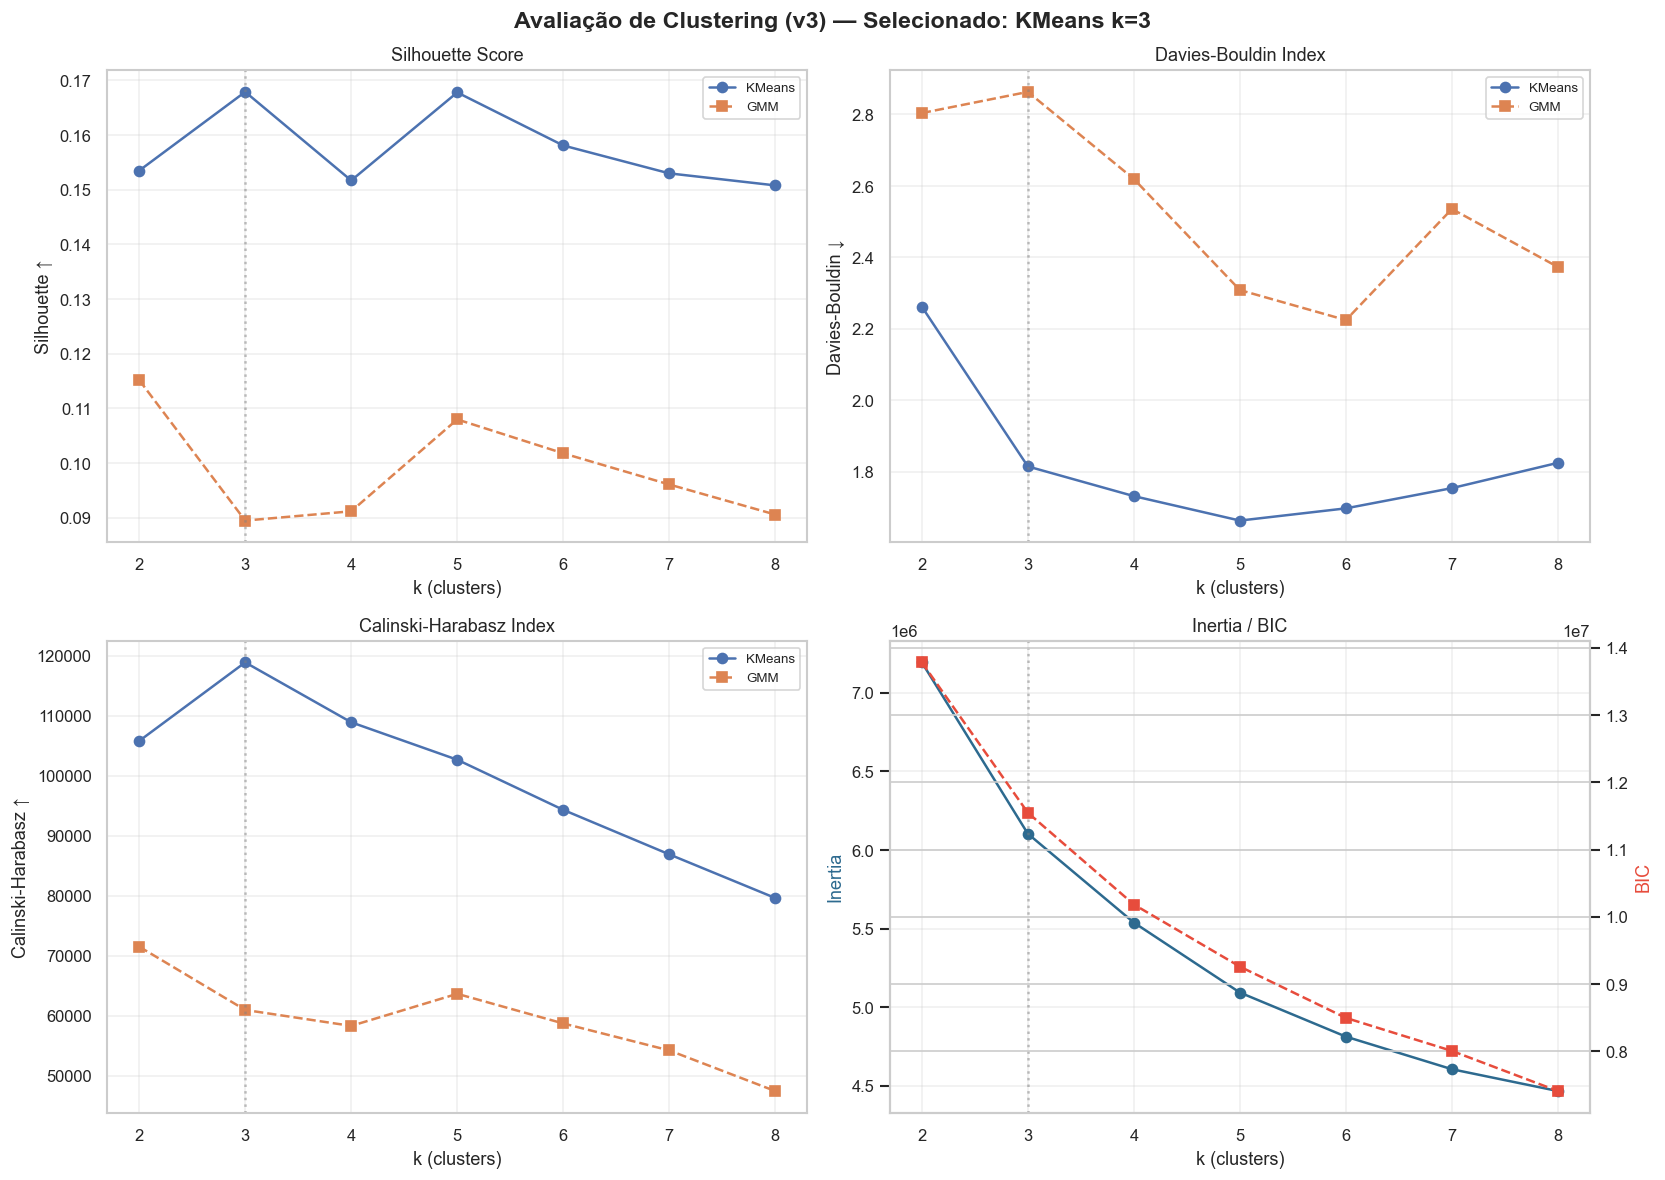

In [19]:
# Guard: verificar que a célula de seleção do modelo já foi executada
if "best_k" not in dir() or "best_algo" not in dir():
    raise RuntimeError("Execute a célula de seleção do modelo (Cell 24) antes desta visualização.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for algo, marker, ls in [("KMeans", "o", "-"), ("GMM", "s", "--")]:
    subset = [r for r in resultados if r["algoritmo"] == algo]
    ks = [r["n_clusters"] for r in subset]
    axes[0, 0].plot(ks, [r["silhouette"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[0, 1].plot(ks, [r["davies_bouldin"] for r in subset], marker=marker, ls=ls, label=algo)
    axes[1, 0].plot(ks, [r["calinski_harabasz"] for r in subset], marker=marker, ls=ls, label=algo)

# DBSCAN ponto
dbscan_plot = [r for r in resultados if r["algoritmo"] == "DBSCAN" and r["silhouette"] is not None]
if dbscan_plot:
    db_r = dbscan_plot[0]
    axes[0, 0].scatter([db_r["n_clusters"]], [db_r["silhouette"]], marker="D", s=100, c="green",
                        zorder=5, label=f"DBSCAN (k={db_r['n_clusters']})", edgecolors="black")
    axes[0, 1].scatter([db_r["n_clusters"]], [db_r["davies_bouldin"]], marker="D", s=100, c="green",
                        zorder=5, edgecolors="black")
    axes[1, 0].scatter([db_r["n_clusters"]], [db_r["calinski_harabasz"]], marker="D", s=100, c="green",
                        zorder=5, edgecolors="black")

# Inertia (KMeans)
km_sub = [r for r in resultados if r["algoritmo"] == "KMeans"]
axes[1, 1].plot([r["n_clusters"] for r in km_sub], [r["inertia"] for r in km_sub], "o-", color="#2d6a8f", label="Inertia (KMeans)")
ax_bic = axes[1, 1].twinx()
gmm_sub = [r for r in resultados if r["algoritmo"] == "GMM"]
ax_bic.plot([r["n_clusters"] for r in gmm_sub], [r["bic"] for r in gmm_sub], "s--", color="#e74c3c", label="BIC (GMM)")

axes[0, 0].set_ylabel("Silhouette ↑"); axes[0, 0].set_title("Silhouette Score"); axes[0, 0].legend(fontsize=8)
axes[0, 1].set_ylabel("Davies-Bouldin ↓"); axes[0, 1].set_title("Davies-Bouldin Index"); axes[0, 1].legend(fontsize=8)
axes[1, 0].set_ylabel("Calinski-Harabasz ↑"); axes[1, 0].set_title("Calinski-Harabasz Index"); axes[1, 0].legend(fontsize=8)
axes[1, 1].set_ylabel("Inertia", color="#2d6a8f"); axes[1, 1].set_title("Inertia / BIC")
ax_bic.set_ylabel("BIC", color="#e74c3c")
for ax in axes.flat:
    ax.set_xlabel("k (clusters)")
    ax.grid(True, alpha=0.3)
    ax.axvline(best_k, color="gray", linestyle=":", alpha=0.5)

fig.suptitle(f"Avaliação de Clustering (v3) — Selecionado: {best_algo} k={best_k}", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_02_metricas_clustering.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "metricas_clustering", fig, "S1c_02_metricas_clustering.png")
plt.show()

### 11.2 PCA 2D

**Objetivo:** Projetar o espaço multidimensional das features para 2 componentes principais via PCA (GPU), colorindo os pontos pela atribuição de cluster.

**Justificativa:** A projeção PCA 2D permite validar visualmente a separação entre clusters. O percentual de variância explicada pelas duas primeiras componentes é reportado para avaliar a representatividade da projeção.


PCA na GPU...
  Variância PC1+PC2: 40.8%
[db_utils] Imagem 'pca_clusters' salva para etapa s1c


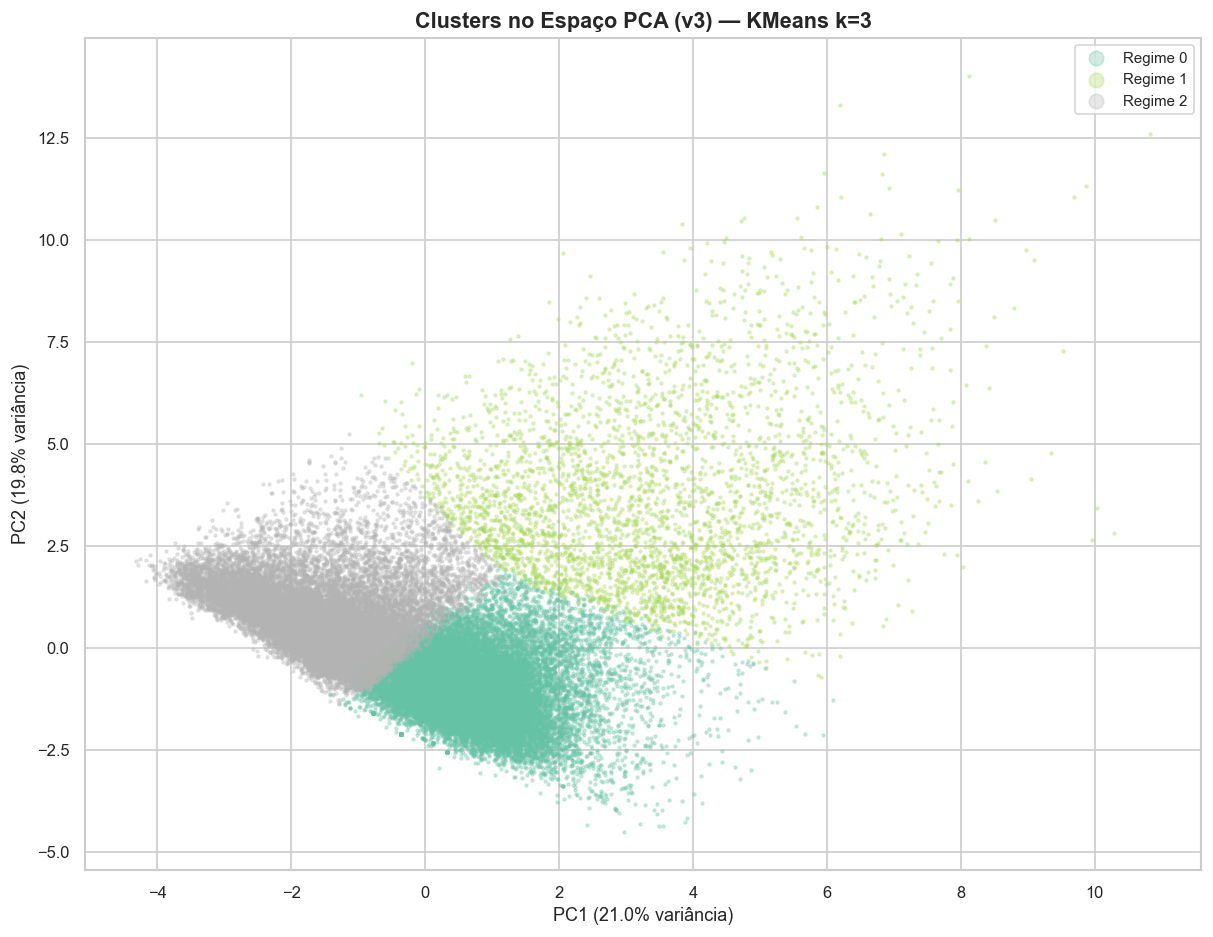

In [20]:
print("PCA na GPU...")
X_pca, var_explained = pca_gpu(X_tensor, n_components=2)
print(f"  Variância PC1+PC2: {sum(var_explained[:2])*100:.1f}%")

n_sample = min(50000, len(X_pca))
idx_sample = np.random.RandomState(42).choice(len(X_pca), n_sample, replace=False)

fig, ax = plt.subplots(figsize=(12, 9))
for rid in range(best_k):
    mask = best_labels[idx_sample] == rid
    ax.scatter(X_pca[idx_sample[mask], 0], X_pca[idx_sample[mask], 1],
               c=[colors_regime[rid]], s=3, alpha=0.3, label=f"Regime {rid}")

ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variância)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variância)")
ax.set_title(f"Clusters no Espaço PCA (v3) — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=9, markerscale=5)
fig.savefig(FIGURES_DIR / "S1c_03_pca_clusters.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "pca_clusters", fig, "S1c_03_pca_clusters.png")
plt.show()

### 11.3 Distribuição de TPH por Regime

**Objetivo:** Apresentar a distribuição da taxa de alimentação (TPH) por regime operacional, utilizando histograma e boxplot.

**Justificativa:** A taxa de alimentação é a variável operacional mais crítica para a interpretação dos regimes. Essa visualização permite distinguir regimes de alta carga, carga moderada e operação instável, traduzindo os clusters matemáticos em significado operacional.


[db_utils] Imagem 'tph_por_regime' salva para etapa s1c


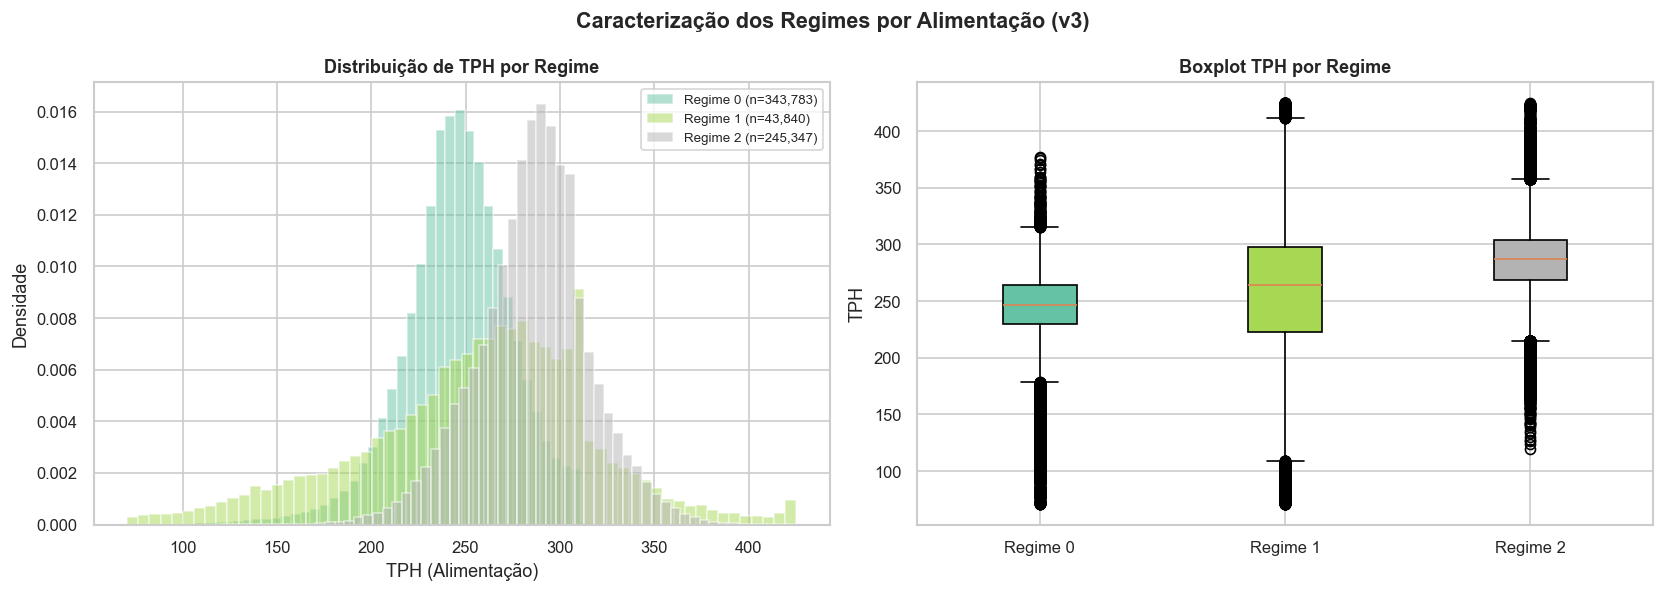

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rid in range(best_k):
    mask = df_clean_regime["regime"] == rid
    axes[0].hist(df_clean_regime.loc[mask, col_tph], bins=60, alpha=0.5,
                 color=colors_regime[rid], label=f"Regime {rid} (n={mask.sum():,})", density=True)

axes[0].set_xlabel("TPH (Alimentação)")
axes[0].set_ylabel("Densidade")
axes[0].set_title("Distribuição de TPH por Regime", fontweight="bold")
axes[0].legend(fontsize=8)

data_box = [df_clean_regime.loc[df_clean_regime["regime"] == r, col_tph].values for r in range(best_k)]
bp = axes[1].boxplot(data_box, labels=[f"Regime {r}" for r in range(best_k)], patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors_regime[i])
axes[1].set_ylabel("TPH")
axes[1].set_title("Boxplot TPH por Regime", fontweight="bold")

fig.suptitle("Caracterização dos Regimes por Alimentação (v3)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_04_tph_por_regime.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "tph_por_regime", fig, "S1c_04_tph_por_regime.png")
plt.show()


### 11.4 Energia Específica por Regime

**Objetivo:** Analisar o consumo de energia específica (kWh/t) por regime operacional identificado.

**Justificativa:** A energia específica é o principal indicador de eficiência energética da moagem. Menor energia específica para um mesmo patamar de throughput indica melhor desempenho de cominuição, sendo fundamental para a avaliação da qualidade de cada regime.


[db_utils] Imagem 'energia_por_regime' salva para etapa s1c


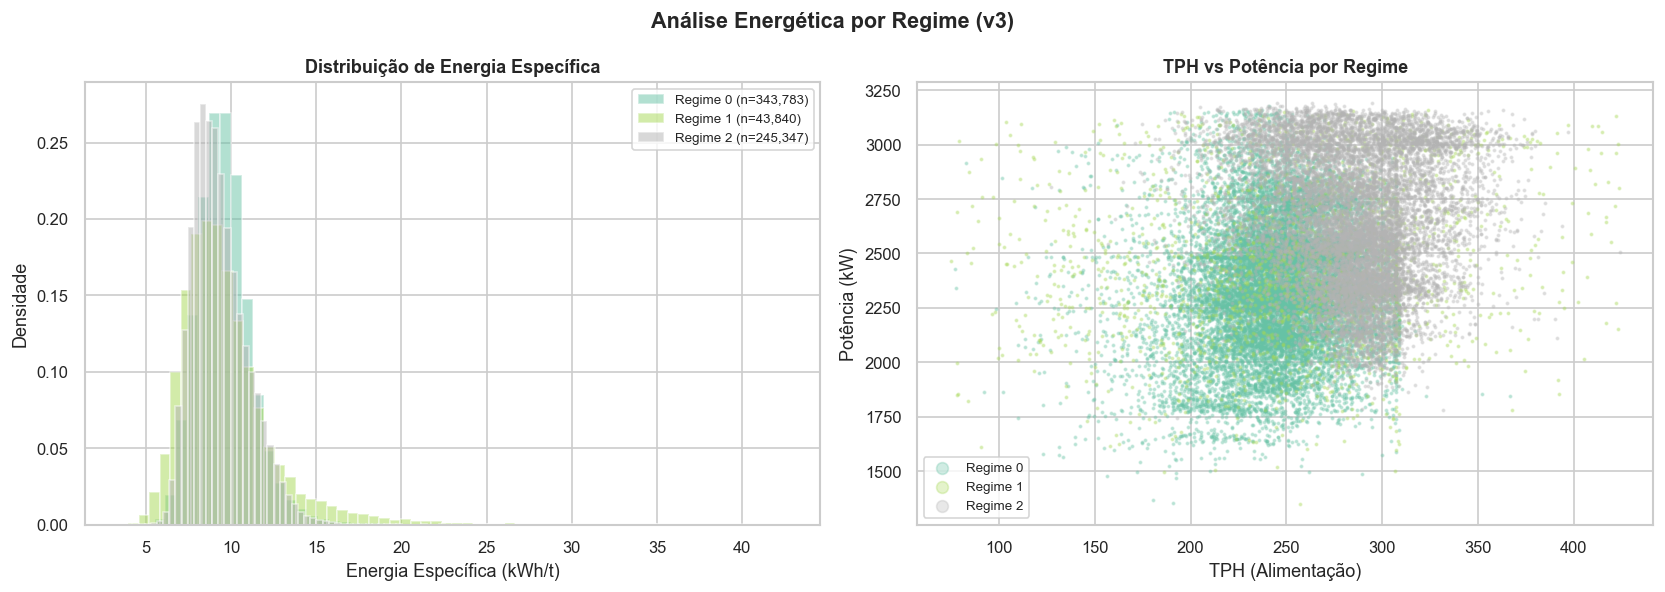

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rid in range(best_k):
    mask = df_clean_regime["regime"] == rid
    ee_vals = df_clean_regime.loc[mask, "FEAT_energia_especifica"].dropna()
    if len(ee_vals) > 0:
        axes[0].hist(ee_vals, bins=60, alpha=0.5, color=colors_regime[rid],
                     label=f"Regime {rid} (n={len(ee_vals):,})", density=True)

axes[0].set_xlabel("Energia Específica (kWh/t)")
axes[0].set_ylabel("Densidade")
axes[0].set_title("Distribuição de Energia Específica", fontweight="bold")
axes[0].legend(fontsize=8)

# Scatter TPH vs Potência colorido por regime
n_sample_sc = min(30000, len(df_clean_regime))
idx_sc = np.random.RandomState(42).choice(len(df_clean_regime), n_sample_sc, replace=False)
df_sc = df_clean_regime.iloc[idx_sc]

for rid in range(best_k):
    mask = df_sc["regime"] == rid
    axes[1].scatter(df_sc.loc[mask, col_tph], df_sc.loc[mask, col_pot],
                    c=[colors_regime[rid]], s=2, alpha=0.3, label=f"Regime {rid}")

axes[1].set_xlabel("TPH (Alimentação)")
axes[1].set_ylabel("Potência (kW)")
axes[1].set_title("TPH vs Potência por Regime", fontweight="bold")
axes[1].legend(fontsize=8, markerscale=5)

fig.suptitle("Análise Energética por Regime (v3)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_05_energia_por_regime.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "energia_por_regime", fig, "S1c_05_energia_por_regime.png")
plt.show()


### 11.5 Radar Chart dos Centroides

**Objetivo:** Apresentar um gráfico spider/radar com as 10 variáveis mais discriminantes entre os regimes, normalizadas, sobrepondo os centroides de cada cluster.

**Justificativa:** O radar chart destaca a assinatura operacional de cada regime, evidenciando quais variáveis de processo diferenciam os clusters de forma mais significativa.


[db_utils] Imagem 'radar_centroides' salva para etapa s1c


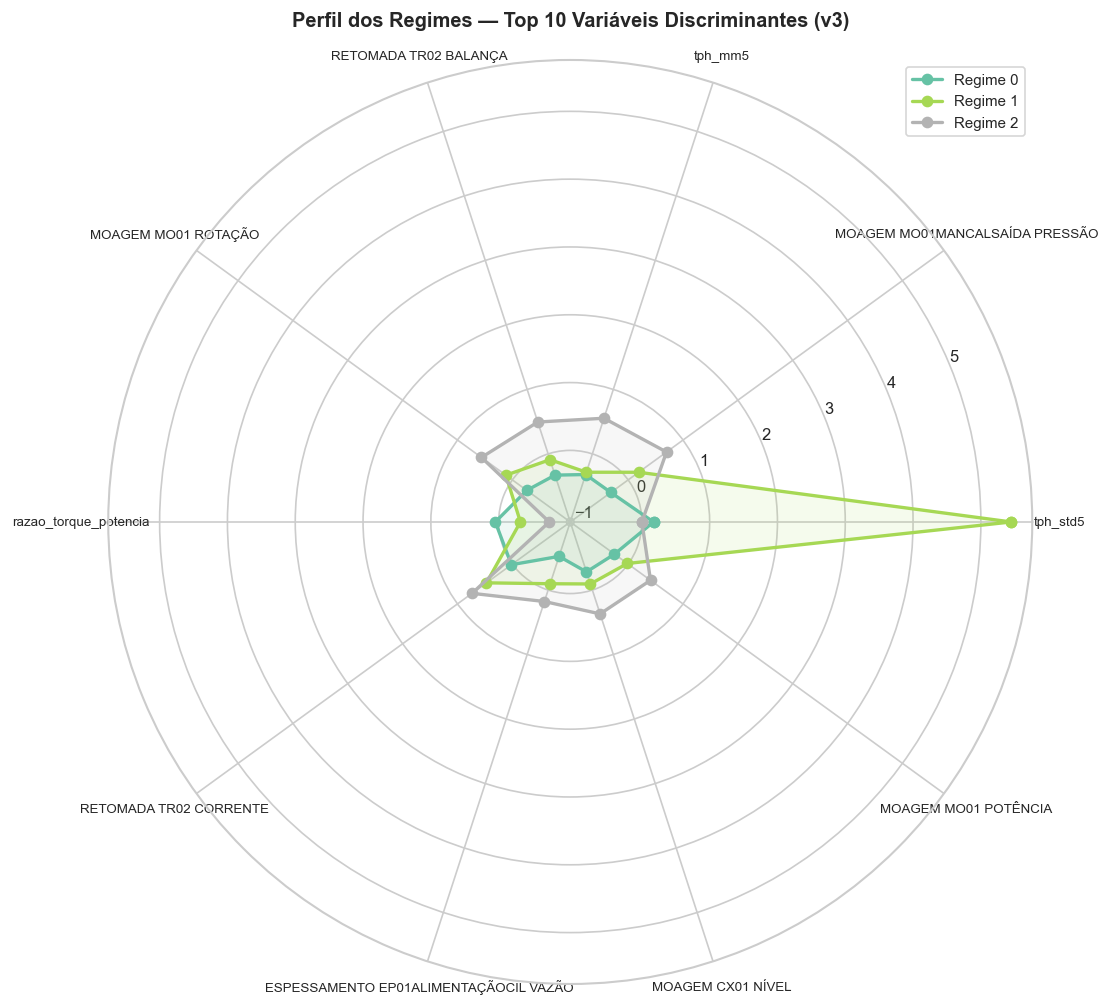

In [23]:
centroides_norm = pd.DataFrame(scaler.transform(centroides_orig.values),
                                columns=COLS_CLUSTER, index=centroides_orig.index)

var_disc = centroides_norm.std(axis=0).sort_values(ascending=False)
top_vars = var_disc.head(10).index.tolist()
labels_radar = [NOMES_CURTOS.get(v, v.replace("FEAT_", "")) for v in top_vars]

angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for rid in range(best_k):
    vals = centroides_norm.loc[rid, top_vars].values.tolist()
    vals += [vals[0]]
    ax.plot(angles, vals, "o-", color=colors_regime[rid], linewidth=2, label=f"Regime {rid}")
    ax.fill(angles, vals, color=colors_regime[rid], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=8)
ax.set_title("Perfil dos Regimes — Top 10 Variáveis Discriminantes (v3)", fontsize=12, fontweight="bold", pad=20)
if SHOW_LEGEND: ax.legend(loc="upper right", fontsize=9)
fig.savefig(FIGURES_DIR / "S1c_06_radar_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "radar_centroides", fig, "S1c_06_radar_centroides.png")
plt.show()


### 11.6 Série Temporal dos Regimes

**Objetivo:** Visualizar a atribuição de regime ao longo do tempo, com reamostragem horária (moda do regime por hora).

**Justificativa:** A análise temporal dos regimes revela padrões de estabilidade operacional, frequência de transições entre regimes e possíveis efeitos sazonais ou de turno, fornecendo insights para a análise temporal aprofundada da Sprint 1d.


[db_utils] Imagem 'serie_temporal_regimes' salva para etapa s1c


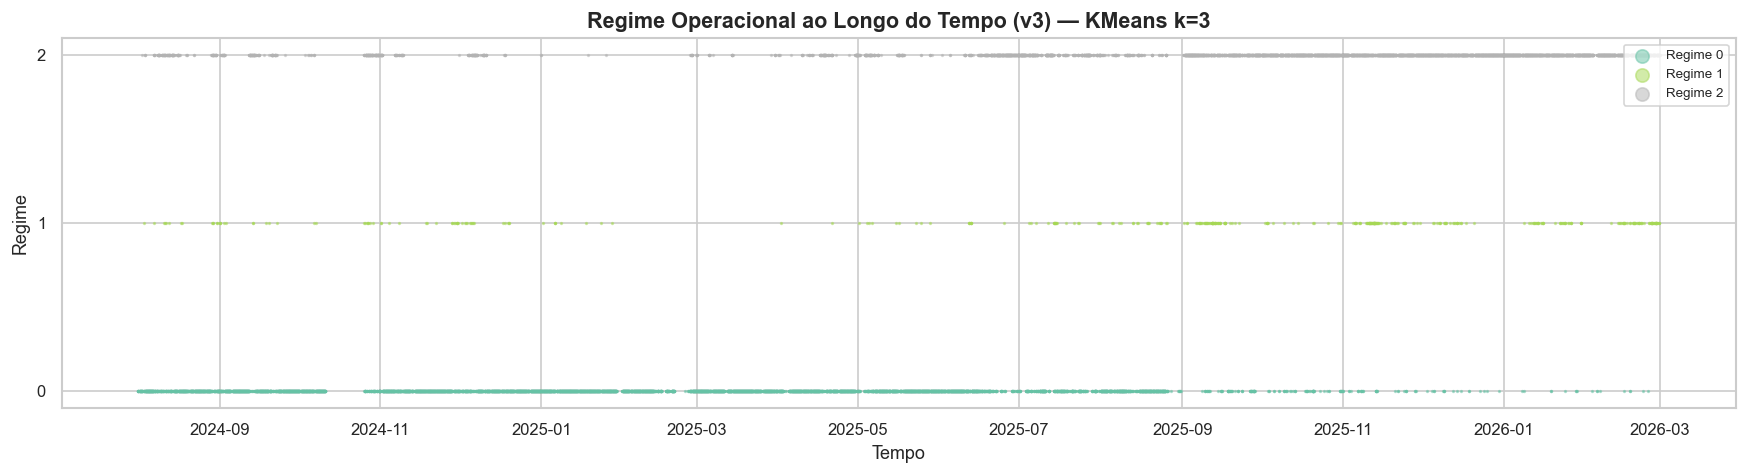

In [24]:
df_ts = df_clean_regime[["regime"]].copy()
regime_h = df_ts["regime"].resample("1h").agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan).dropna()

fig, ax = plt.subplots(figsize=(18, 4))
for rid in range(best_k):
    mask = regime_h == rid
    ax.scatter(regime_h.index[mask], regime_h[mask], c=[colors_regime[rid]], s=1, alpha=0.5, label=f"Regime {rid}")

ax.set_xlabel("Tempo")
ax.set_ylabel("Regime")
ax.set_yticks(range(best_k))
ax.set_title(f"Regime Operacional ao Longo do Tempo (v3) — {best_algo} k={best_k}", fontsize=13, fontweight="bold")
if SHOW_LEGEND: ax.legend(fontsize=8, markerscale=8, loc="upper right")
fig.savefig(FIGURES_DIR / "S1c_07_serie_temporal_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "serie_temporal_regimes", fig, "S1c_07_serie_temporal_regimes.png")
plt.show()


### 11.7 Heatmap dos Centroides

**Objetivo:** Gerar um heatmap dos valores dos centroides de todos os regimes, normalizados pelo RobustScaler, abrangendo todas as features utilizadas no clustering.

**Justificativa:** O heatmap fornece uma visão completa e simultânea de como cada variável de processo se comporta em cada regime, complementando o radar chart (que mostra apenas as 10 mais discriminantes) com a totalidade das features.


[db_utils] Imagem 'heatmap_centroides' salva para etapa s1c


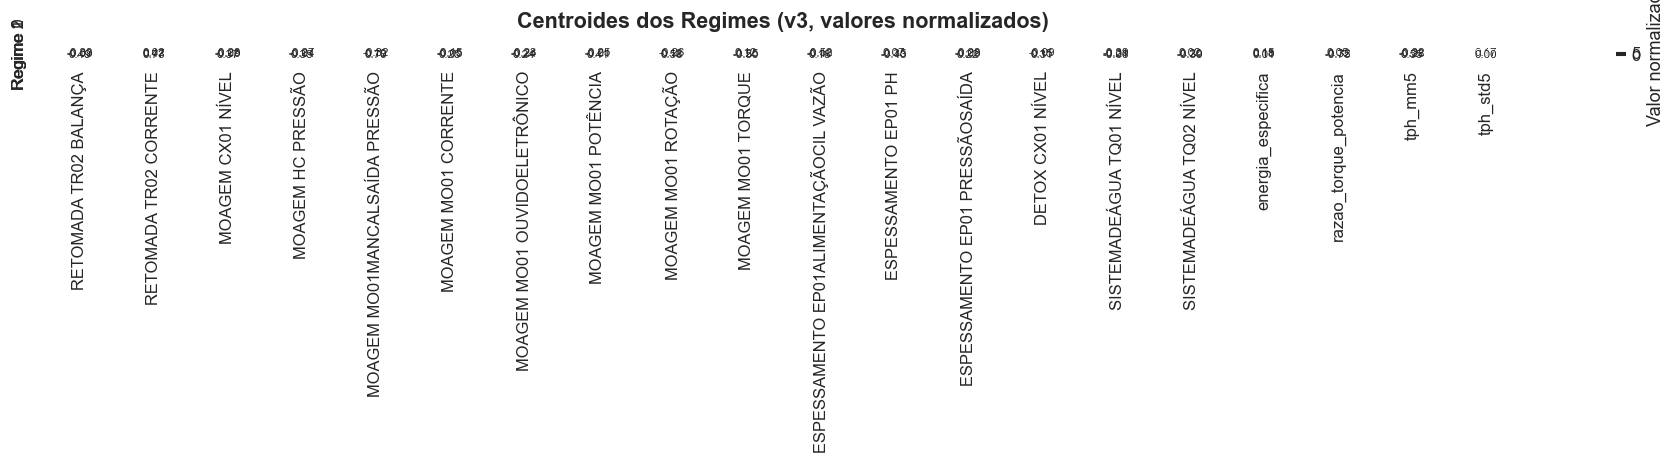

In [25]:
fig, ax = plt.subplots(figsize=(16, max(4, best_k * 1.2)))
labels_heat = [NOMES_CURTOS.get(c, c.replace("FEAT_", "")) for c in COLS_CLUSTER]
sns.heatmap(centroides_norm[COLS_CLUSTER].values, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.3, xticklabels=labels_heat,
            yticklabels=[f"Regime {r}" for r in range(best_k)],
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8, "label": "Valor normalizado"})
ax.set_title("Centroides dos Regimes (v3, valores normalizados)", fontsize=13, fontweight="bold", pad=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1c_08_heatmap_centroides.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "heatmap_centroides", fig, "S1c_08_heatmap_centroides.png")
plt.show()


## 12. Comparação v1 vs v2 vs v3

Compara as métricas do melhor modelo de cada versão:
- **v1**: Pipeline original (StandardScaler, todas as variáveis, sem filtro)
- **v2**: Preprocessing avançado (RobustScaler, seleção de features, Hampel, colinearidade)
- **v3**: Filtro de operação estável + feature engineering + preprocessing avançado


In [26]:
# ── Carregar resultados v1 e v2 do banco (fallback para CSV local) ──
from db_utils import carregar_dataframe
cols_comp = ["algoritmo", "n_clusters", "silhouette", "davies_bouldin", "calinski_harabasz"]

try:
    # Tentar banco primeiro
    df_v1 = carregar_dataframe("s1c_v1_metricas_clustering")
    df_v1 = df_v1[df_v1["selecionado"] == True][cols_comp]
    df_v2 = carregar_dataframe("s1c_v2_metricas_clustering")
    df_v2 = df_v2[df_v2["selecionado"] == True][cols_comp]
    has_comparison = len(df_v1) > 0 and len(df_v2) > 0
    if has_comparison:
        print("Dados v1 e v2 carregados do banco.")
except Exception:
    # Fallback: CSV local
    try:
        df_v1 = pd.read_csv(DATA_PROC / "metricas_clustering_v1.csv")
        df_v1 = df_v1[df_v1["selecionado"] == True][cols_comp]
        df_v2 = pd.read_csv(DATA_PROC / "metricas_clustering_v2.csv")
        df_v2 = df_v2[df_v2["selecionado"] == True][cols_comp]
        has_comparison = len(df_v1) > 0 and len(df_v2) > 0
        if has_comparison:
            print("Dados v1 e v2 carregados dos CSVs locais.")
    except Exception as e:
        print(f"Não foi possível carregar dados v1/v2: {e}")
        print("Execute os notebooks v1 e v2 primeiro.")
        has_comparison = False
        df_v1 = pd.DataFrame()
        df_v2 = pd.DataFrame()

[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v1_metricas_clustering
[db_utils] 15 linhas carregadas de otimizar_moagem_aura.s1c_v2_metricas_clustering
Dados v1 e v2 carregados do banco.


In [27]:
# ── Montar tabela comparativa ──
v3_best = {
    "versao": "v3",
    "algoritmo": best_algo,
    "n_clusters": best_k,
    "silhouette": best["silhouette"],
    "davies_bouldin": best["davies_bouldin"],
    "calinski_harabasz": best["calinski_harabasz"],
    "n_registros": len(df_clean),
    "n_variaveis": len(COLS_CLUSTER),
    "filtro_estavel": "Sim",
    "feat_engineering": "Sim",
}

rows_comp = []
if has_comparison and len(df_v1) > 0:
    r1 = df_v1.iloc[0]
    rows_comp.append({
        "versao": "v1", "algoritmo": r1["algoritmo"], "n_clusters": int(r1["n_clusters"]),
        "silhouette": r1["silhouette"], "davies_bouldin": r1["davies_bouldin"],
        "calinski_harabasz": r1["calinski_harabasz"],
        "n_registros": 632985, "n_variaveis": 26,
        "filtro_estavel": "Não", "feat_engineering": "Não",
    })
if has_comparison and len(df_v2) > 0:
    r2 = df_v2.iloc[0]
    rows_comp.append({
        "versao": "v2", "algoritmo": r2["algoritmo"], "n_clusters": int(r2["n_clusters"]),
        "silhouette": r2["silhouette"], "davies_bouldin": r2["davies_bouldin"],
        "calinski_harabasz": r2["calinski_harabasz"],
        "n_registros": 632985, "n_variaveis": "~16",
        "filtro_estavel": "Não", "feat_engineering": "Não",
    })
rows_comp.append(v3_best)

df_comp = pd.DataFrame(rows_comp)
print("\n" + "=" * 80)
print("  COMPARAÇÃO DE VERSÕES DO CLUSTERING")
print("=" * 80)
display(df_comp.style.highlight_max(subset=["silhouette", "calinski_harabasz"], color="#d4edda")
                     .highlight_min(subset=["davies_bouldin"], color="#d4edda")
                     .format(precision=4))



  COMPARAÇÃO DE VERSÕES DO CLUSTERING


,versao,algoritmo,n_clusters,silhouette,davies_bouldin,calinski_harabasz,n_registros,n_variaveis,filtro_estavel,feat_engineering
0,v1,KMeans,2,0.1608,2.1965,122690.9000,632985,26,Não,Não
1,v2,KMeans,3,0.1763,1.8781,109090.7000,632985,~16,Não,Não
2,v3,KMeans,3,0.1679,1.8152,118907.7000,632970,20,Sim,Sim


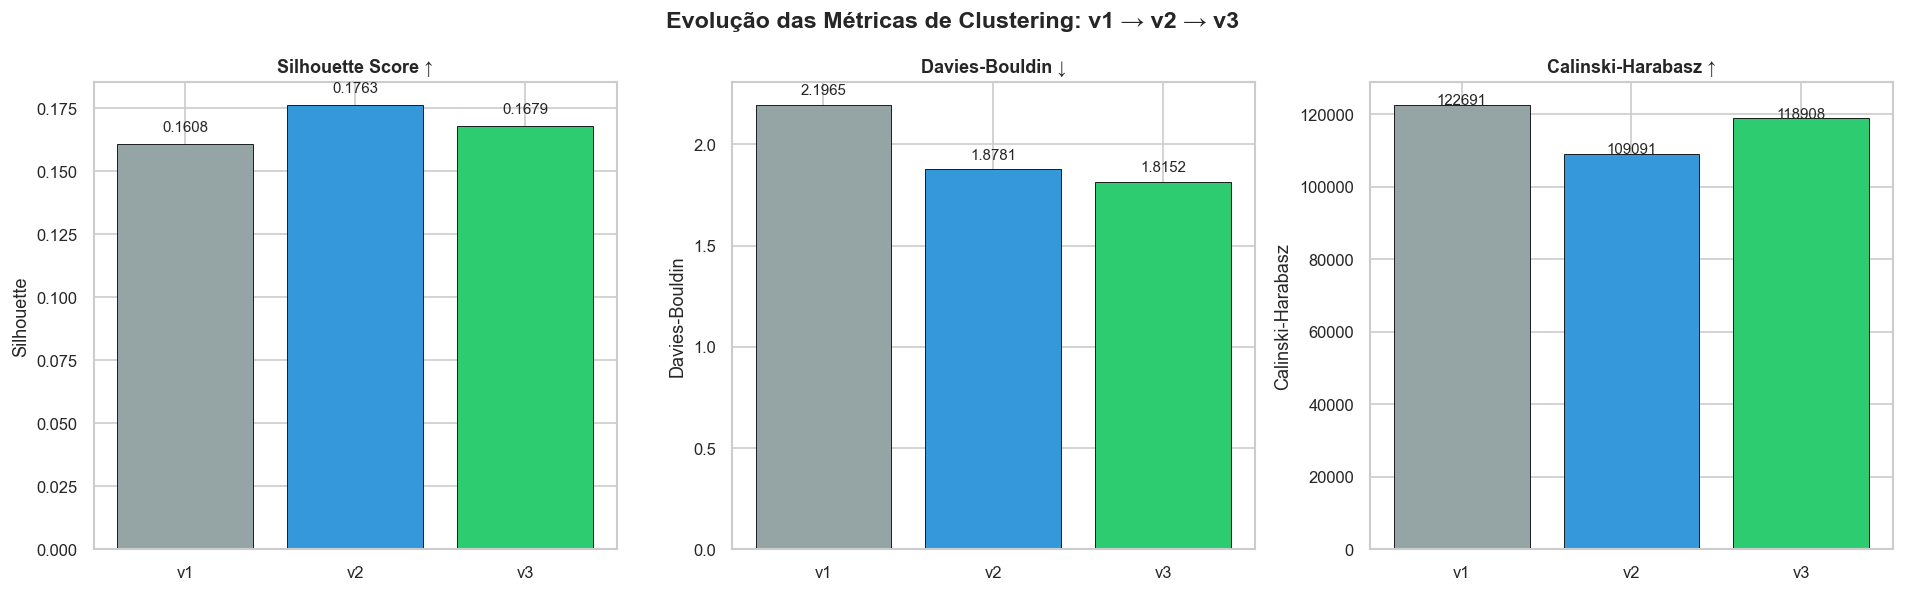

In [28]:
# ── Gráfico comparativo ──
if has_comparison and len(rows_comp) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    versoes = [r["versao"] for r in rows_comp]
    colors_v = ["#95a5a6", "#3498db", "#2ecc71"][:len(versoes)]

    # Silhouette
    vals_sil = [r["silhouette"] for r in rows_comp]
    bars = axes[0].bar(versoes, vals_sil, color=colors_v, edgecolor="black", linewidth=0.5)
    axes[0].set_title("Silhouette Score ↑", fontweight="bold")
    axes[0].set_ylabel("Silhouette")
    for bar, val in zip(bars, vals_sil):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.4f}", ha="center", fontsize=9)

    # Davies-Bouldin
    vals_db = [r["davies_bouldin"] for r in rows_comp]
    bars = axes[1].bar(versoes, vals_db, color=colors_v, edgecolor="black", linewidth=0.5)
    axes[1].set_title("Davies-Bouldin ↓", fontweight="bold")
    axes[1].set_ylabel("Davies-Bouldin")
    for bar, val in zip(bars, vals_db):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f"{val:.4f}", ha="center", fontsize=9)

    # Calinski-Harabasz
    vals_ch = [r["calinski_harabasz"] for r in rows_comp]
    bars = axes[2].bar(versoes, vals_ch, color=colors_v, edgecolor="black", linewidth=0.5)
    axes[2].set_title("Calinski-Harabasz ↑", fontweight="bold")
    axes[2].set_ylabel("Calinski-Harabasz")
    for bar, val in zip(bars, vals_ch):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f"{val:.0f}", ha="center", fontsize=9)

    fig.suptitle("Evolução das Métricas de Clustering: v1 → v2 → v3", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "S1c_09_comparacao_v1_v2_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Gráfico comparativo não gerado — dados v1/v2 não disponíveis.")
    print("Execute os notebooks v1 e v2 primeiro para gerar a comparação completa.")


## 13. Salvar Saídas Locais

**Objetivo:** Persistir todas as saídas do pipeline em disco e no banco de dados PostgreSQL, garantindo reprodutibilidade e integração com o dashboard.

**Saídas em disco:** parquet (dataset com clusters), CSV (métricas de clustering, descrição dos regimes).

**Saídas no banco:**
- `dados_com_clusters` — dataset completo com coluna `regime` (tabela canônica do pipeline)
- `s1c_metricas_clustering` — métricas de validação (Silhouette, DB, CH) por algoritmo/k
- `s1c_todos_testes` — log completo de todos os testes de clustering (KMeans + DBSCAN + GMM)
- `s1c_regimes` — caracterização dos regimes (n_samples, percentual, TPH)
- `s1c_regime_centroides` — centroides por regime e variável (formato longo)
- Figuras salvas via `salvar_imagem()` ao longo do notebook

**Justificativa:** A persistência dual (disco + banco) assegura que os resultados estão disponíveis tanto para análise local e versionamento quanto para consumo pelo dashboard em tempo real.

In [29]:
# ── Salvar dataset com regimes ──
df_output = df_estavel.reset_index()
df_output["regime"] = np.nan
# Atribuir regimes alinhando por índice (não por posição) para evitar mismatch
regime_series = df_clean_regime["regime"].rename("_regime_tmp")
df_output = df_output.merge(
    regime_series.reset_index().rename(columns={regime_series.index.name or "index": "Timestamp", "_regime_tmp": "regime_aligned"}),
    on="Timestamp", how="left"
)
df_output["regime"] = df_output["regime_aligned"].astype("Int64")
df_output = df_output.drop(columns=["regime_aligned"])

output_path = DATA_PROC / "dados_com_clusters_v3.parquet"
df_output.to_parquet(output_path, index=False)
print(f"Dataset salvo: {output_path}")
print(f"  {len(df_output):,} registros, {len(df_output.columns)} colunas")

# ── Salvar métricas ──
df_metricas = pd.DataFrame([{
    "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
    "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
    "calinski_harabasz": r["calinski_harabasz"], "inertia": r.get("inertia"),
    "bic": r.get("bic"), "selecionado": r["selecionado"],
} for r in resultados])
metricas_path = DATA_PROC / "metricas_clustering_v3.csv"
df_metricas.to_csv(metricas_path, index=False)
print(f"Métricas salvas: {metricas_path}")

# ── Salvar regimes ──
regimes_path = DATA_PROC / "regimes_v3.csv"
df_regimes.to_csv(regimes_path, index=False)
print(f"Regimes salvos: {regimes_path}")

# ── Salvar log completo de TODOS os testes (KMeans + DBSCAN + GMM) ──
todos_testes = []
# KMeans e GMM (já em resultados)
for r in resultados:
    todos_testes.append({
        "algoritmo": r["algoritmo"], "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": r["davies_bouldin"],
        "calinski_harabasz": r["calinski_harabasz"],
        "inertia": r.get("inertia"), "bic": r.get("bic"),
        "eps": None, "min_samples": None, "pct_noise": None,
        "selecionado": r["selecionado"],
    })
# DBSCAN sweep (todas as combinações)
for r in dbscan_results:
    todos_testes.append({
        "algoritmo": "DBSCAN", "n_clusters": r["n_clusters"],
        "silhouette": r["silhouette"], "davies_bouldin": None,
        "calinski_harabasz": None,
        "inertia": None, "bic": None,
        "eps": r["eps"], "min_samples": r["min_samples"],
        "pct_noise": r["pct_noise"],
        "selecionado": False,
    })
df_todos_testes = pd.DataFrame(todos_testes)
df_todos_testes.to_csv(DATA_PROC / "todos_testes_clustering_v3.csv", index=False)
print(f"Todos os testes: {len(df_todos_testes)} registros")

# ==============================================================================
# Persistência no PostgreSQL
# ==============================================================================

# 1. dados_com_clusters — dataset completo com coluna regime
#    Selecionar apenas colunas do schema (variáveis de processo + Timestamp + regime)
cols_processo = [c for c in df_output.columns if c.endswith("_pipoint")]
cols_db = ["Timestamp"] + cols_processo + ["regime"]
salvar_dataframe(df_output[cols_db], "s1c_v3_dados_com_clusters")

# 2. s1c_metricas_clustering — comparação de algoritmos
salvar_dataframe(df_metricas, "s1c_v3_metricas_clustering")

# 2b. s1c_todos_testes — log completo de todos os testes realizados
salvar_dataframe(df_todos_testes, "s1c_v3_todos_testes", modo="replace")
print(f"  s1c_todos_testes: {len(df_todos_testes)} registros")

# 3. s1c_regimes — caracterização dos regimes
df_regimes_db = df_regimes[["regime", "n_samples", "percentual", "tph_medio", "tph_std"]].copy()
salvar_dataframe(df_regimes_db, "s1c_v3_regimes")

# 4. s1c_regime_centroides — centróides por variável por regime
centroides_melted = centroides_orig.reset_index().melt(
    id_vars="regime", var_name="variavel", value_name="valor_centroide"
)
salvar_dataframe(centroides_melted, "s1c_v3_regime_centroides")

print("\nDados de clustering salvos no PostgreSQL.")

# Liberar GPU (se disponível)
del X_tensor
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nFiguras salvas em: {FIGURES_DIR}")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}")

Dataset salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\dados_com_clusters_v3.parquet
  632,970 registros, 34 colunas
Métricas salvas: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\metricas_clustering_v3.csv
Regimes salvos: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\regimes_v3.csv
Todos os testes: 59 registros
[db_utils] s1c_v3_dados_com_clusters: 500,000 / 632,970 (79.0%)
[db_utils] s1c_v3_dados_com_clusters: 632,970 / 632,970 (100.0%)
[db_utils] 632,970 linhas salvas em otimizar_moagem_aura.s1c_v3_dados_com_clusters
[db_utils] 15 linhas salvas em otimizar_moagem_aura.s1c_v3_metricas_clustering
[db_utils] 59 linhas salvas em otimizar_moagem_aura.s1c_v3_todos_testes
  s1c_todos_testes: 59 registros
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s1c_v3_regimes
[db_utils] 60 linhas salvas em otimizar_moagem_aura.s1c_v3_regime_centroides

Dados de clustering salvos no PostgreSQL.

Figuras salvas em: C:\ScriptsDatamindsPIP\4-Projeto aplicado\fig

## 14. Resumo da Execução

**Objetivo:** Apresentar um sumário consolidado da execução do pipeline de clustering, incluindo: tempo total de processamento, número de registros processados, algoritmo selecionado, distribuição dos regimes e métricas-chave do modelo final.

**Justificativa:** O resumo facilita a documentação e a rastreabilidade das execuções, permitindo comparar rapidamente resultados entre diferentes versões do pipeline.


In [31]:
elapsed = time.time() - t0
print()
print("=" * 70)
print("  RESUMO DO CLUSTERING — v3")
print("=" * 70)
print(f"  Tempo total:              {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"  Registros originais:      {n_total:,}")
print(f"  Operação estável:         {len(df_estavel):,} ({100*len(df_estavel)/n_total:.1f}%)")
print(f"  Registros clustering:     {len(df_clean):,}")
print(f"  Variáveis (features):     {len(COLS_CLUSTER)} (incl. {len(COLS_FEAT)} derivadas)")
print(f"  Algoritmos avaliados:     KMeans, GMM, DBSCAN")
print(f"  Algoritmo selecionado:    {best_algo} k={best_k}")
print(f"  Silhouette:               {best['silhouette']}")
print(f"  Davies-Bouldin:           {best['davies_bouldin']}")
print(f"  Calinski-Harabasz:        {best['calinski_harabasz']}")
print(f"  Variância PCA (2D):       {sum(var_explained[:2])*100:.1f}%")
print(f"  Regimes:")
for _, row in df_regimes.iterrows():
    print(f"    Regime {row['regime']}: {row['n_samples']:>8,} ({row['percentual']:5.1f}%)  "
          f"TPH={row['tph_medio']:.1f} ± {row['tph_std']:.1f}")
print(f"\n  Saídas:")
print(f"    Parquet: {output_path.name}")
print(f"    Métricas: {metricas_path.name}")
print(f"    Figuras: {len(list(FIGURES_DIR.glob('*.png')))} arquivos em {FIGURES_DIR.name}/")
print("=" * 70)


  RESUMO DO CLUSTERING — v3
  Tempo total:              8445s (140.7 min)
  Registros originais:      632,985
  Operação estável:         632,970 (100.0%)
  Registros clustering:     632,970
  Variáveis (features):     20 (incl. 5 derivadas)
  Algoritmos avaliados:     KMeans, GMM, DBSCAN
  Algoritmo selecionado:    KMeans k=3
  Silhouette:               0.1679
  Davies-Bouldin:           1.8152
  Calinski-Harabasz:        118907.7
  Variância PCA (2D):       40.8%
  Regimes:
    Regime 0.0: 343,783.0 ( 54.3%)  TPH=245.4 ± 28.8
    Regime 1.0: 43,840.0 (  6.9%)  TPH=257.2 ± 61.2
    Regime 2.0: 245,347.0 ( 38.8%)  TPH=285.9 ± 29.9

  Saídas:
    Parquet: dados_com_clusters_v3.parquet
    Métricas: metricas_clustering_v3.csv
    Figuras: 9 arquivos em clustering_v3/


In [32]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook (grava outputs em disco)
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)  # Aguardar gravação

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\01_sprint1\clusters\c_clustering_regimes_v3.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True  # Ocultar código, manter outputs
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "CLUSTER_c_clustering_regimes_v3.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\CLUSTER_c_clustering_regimes_v3.html
